# Defining libraries and loading data

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure
import os
import time
from pathlib import Path
import sys
import pandas as pd
from tqdm import tqdm
import json


import torchvision.utils as vutils
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from dataclasses import dataclass

In [ ]:
DATA_DIR = "./data"
OUTPUT_DIR = "./outputs"

BATCH_SIZE = 128
NUM_WORKERS = 2
LEARNING_RATE = 1e-3
LATENT_DIM = 128
dev_EPOCHS = 1
prod_EPOCHS = 100

# VQ specific variables
hidden_channels = (512, 256)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
KAGGLE_MODEL_DIR = Path("./results")

In [4]:
#Make sure GPU torch is instaled and available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("PyTorch version:", torch.__version__) # should be 2.0.1 or later for CUDA support
print("torch version:", torch.version.cuda) # should show CUDA version if available
#Check if GPU is available and set device accordingly
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
PyTorch version: 2.11.0+cu128
torch version: 12.8
GPU: Quadro T1000 with Max-Q Design


In [34]:

def get_datasets(data_dir="./data", dataset_name="mnist"):
    transform = transforms.Compose([
        transforms.ToTensor()
    ])

    if dataset_name == "mnist":
        train_set = datasets.MNIST(root=data_dir, train=True, download=True, transform=transform)
        test_set = datasets.MNIST(root=data_dir, train=False, download=True, transform=transform)
        in_channels, input_size = 1, 28

    elif dataset_name == "fashion-mnist":
        train_set = datasets.FashionMNIST(root=data_dir, train=True, download=True, transform=transform)
        test_set = datasets.FashionMNIST(root=data_dir, train=False, download=True, transform=transform)
        in_channels, input_size = 1, 28

    elif dataset_name == "cifar10":
        train_set = datasets.CIFAR10(root=data_dir, train=True, download=True, transform=transform)
        test_set = datasets.CIFAR10(root=data_dir, train=False, download=True, transform=transform)
        in_channels, input_size = 3, 32

    else:
        raise ValueError(f"Unknown dataset: {dataset_name}")

    return train_set, test_set, in_channels, input_size

def get_dataloaders(data_dir="./data", dataset_name="mnist", batch_size=128, num_workers=2):
    train_set, test_set, in_channels, input_size = get_datasets(data_dir, dataset_name)

    train_loader = DataLoader(
        train_set, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=True
    )
    test_loader = DataLoader(
        test_set, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=True
    )

    return train_loader, test_loader, in_channels, input_size

def show_batch(images, n=8, title="Batch"):
    images = images[:n].cpu()
    grid = vutils.make_grid(images, nrow=n, padding=2)
    plt.figure(figsize=(n * 1.5, 2))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray" if images.shape[1] == 1 else None)
    plt.title(title)
    plt.axis("off")
    plt.show()

In [35]:
mnist_train, mnist_test, mnist_in_channels, mnist_input_size = get_dataloaders(
    data_dir=DATA_DIR,
    dataset_name="mnist",
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)
fashion_mnist_train, fashion_mnist_test, fashion_mnist_in_channels, fashion_mnist_input_size = get_dataloaders(
    data_dir=DATA_DIR,
    dataset_name="fashion-mnist",
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)
cifar10_train, cifar10_test, cifar10_in_channels, cifar10_input_size = get_dataloaders(
    data_dir=DATA_DIR,
    dataset_name="cifar10",
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

torch.Size([128, 1, 28, 28]) torch.Size([128])


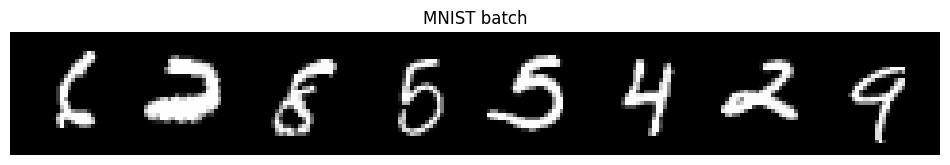

torch.Size([128, 1, 28, 28]) torch.Size([128])


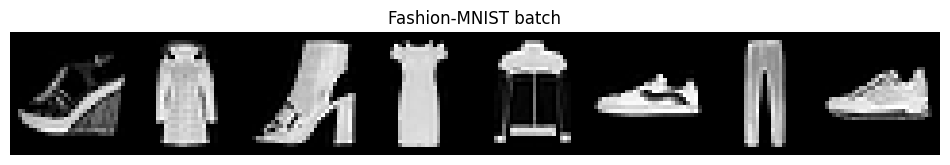

torch.Size([128, 3, 32, 32]) torch.Size([128])


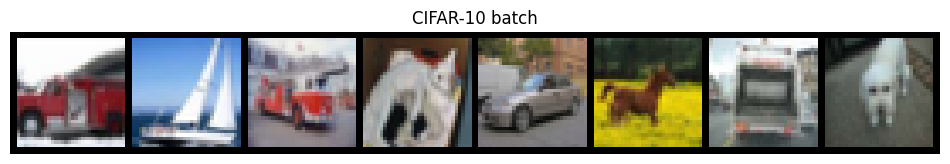

In [36]:
mnist_images, labels = next(iter(mnist_train))
fashion_mnist_images, labels1 = next(iter(fashion_mnist_train))
cifar10_images, labels2 = next(iter(cifar10_train))

print(mnist_images.shape, labels.shape)
show_batch(mnist_images, title="MNIST batch")
print(fashion_mnist_images.shape, labels1.shape)
show_batch(fashion_mnist_images, title="Fashion-MNIST batch")
print(cifar10_images.shape, labels2.shape)
show_batch(cifar10_images, title="CIFAR-10 batch")

# Conv CODE Implementation

In [37]:
class ConvVAE(nn.Module):
    """
    Convolutional Variational Autoencoder for complex image datasets.
    """
    def __init__(self, in_channels, input_size, latent_dim=64, dataset_name="mnist"):
        super(ConvVAE, self).__init__()
        
        self.latent_dim = latent_dim
        self.dataset_name = dataset_name.lower()

        # ==========================================
        # 1. Input Size Type-Check
        # ==========================================
        # If your dataloader returns an int (e.g., 28), convert it to (28, 28)
        if isinstance(input_size, int):
            self.img_height = input_size
            self.img_width = input_size
        else:
            self.img_height = input_size[0]
            self.img_width = input_size[1]


        # ==========================================
        # ENCODER (Conv2d downsamples the image)
        # ==========================================
        # Formula for output size: [(W - Kernel + 2*Pad) / Stride] + 1
        self.leaky_relu = nn.LeakyReLU(0.2)
        self.enc_conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, stride=2, padding=1)
        self.enc_conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        
        
        # --- Dynamic Dimension Calculation ---
        # We pass a dummy tensor of the correct shape through the conv layers 
        # to figure out exactly how many features we need to flatten!
        if self.dataset_name == "cifar10":
            self.enc_conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1)
            
        dummy_x = torch.zeros(1, in_channels, self.img_height, self.img_width)
        dummy_out = self.enc_conv2(self.enc_conv1(dummy_x))

        if self.dataset_name == "cifar10":
            dummy_out = self.enc_conv3(dummy_out)
        
        # Save the shape before flattening so the decoder knows how to unflatten it later
        self.conv_shape = dummy_out.shape[1:] 
        self.flattened_size = dummy_out.numel()
        # -------------------------------------
        
        # Latent space mappings
        self.enc_mean = nn.Linear(self.flattened_size, latent_dim)
        self.enc_logvar = nn.Linear(self.flattened_size, latent_dim)
        
        # ==========================================
        # DECODER (ConvTranspose2d upsamples the image)
        # ==========================================
        
        self.dec_fc = nn.Linear(latent_dim, self.flattened_size)
        if (self.dataset_name == "cifar10"):
            self.dec_conv0 = nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1)
        
        self.dec_conv1 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.dec_conv2 = nn.ConvTranspose2d(32, in_channels, kernel_size=3, stride=2, padding=1, output_padding=1)

    def encode(self, x):
        h = self.leaky_relu(self.enc_conv1(x))
        h = self.leaky_relu(self.enc_conv2(h))
        if (self.dataset_name == "cifar10"):
            h = self.leaky_relu(self.enc_conv3(h))
            
        # Flatten for the linear layer
        h_flat = h.view(h.size(0), -1)
        mean = self.enc_mean(h_flat)
        logvar = self.enc_logvar(h_flat)
        return mean, logvar
        
    def reparameterize(self, mean, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mean + std * eps
        
    def decode(self, z):
        # 1. Map latent vector back to the flattened spatial size
        h = self.leaky_relu(self.dec_fc(z))
        
        # 2. Reshape back to 3D tensor (Channels, Height, Width)
        h = h.view(h.size(0), *self.conv_shape)

        if (self.dataset_name == "cifar10"):
            h = self.leaky_relu(self.dec_conv0(h))
        
        # 3. Upsample back to original image size
        h = self.leaky_relu(self.dec_conv1(h))
        
        # No ReLU on the final output, use Sigmoid (for MNIST/Fashion) or Tanh (if CIFAR is normalized -1 to 1)
        if self.dataset_name == "cifar10":
            x_hat = torch.tanh(self.dec_conv2(h))
        else:
            x_hat =  self.dec_conv2(h)#torch.sigmoid(self.dec_conv2(h))
        return x_hat

    def forward(self, x):
        # Notice we NO LONGER flatten the input 'x' here! It stays as a 2D image.
        mean, logvar = self.encode(x)
        z = self.reparameterize(mean, logvar)
        x_hat = self.decode(z)
        
        return x_hat, mean, logvar

In [38]:
# Loss function for VAE: Reconstruction loss + KL divergence
def vae_loss(reconstructed_x, x_orig, mean, logvar, dataset_name):
    """
    Computes the VAE loss, dynamically selecting the reconstruction 
    loss based on the dataset properties.
    """
    # 1. Reconstruction Loss
    if dataset_name.lower() == "cifar10":
        # MSE is standard for continuous RGB data
        recon_loss = F.mse_loss(reconstructed_x, x_orig, reduction='sum')
    else:
        # BCE is standard for normalized grayscale data [0, 1] (MNIST/Fashion-MNIST)
        recon_loss = F.binary_cross_entropy_with_logits(reconstructed_x, x_orig, reduction='sum')

    # 2. KL Divergence
    KLD = -0.5 * torch.sum(1 + logvar - mean.pow(2) - logvar.exp())
    
    return recon_loss + KLD, recon_loss, KLD

def train_vae(model, train_loader, epochs, optimizer, device, dataset_name, use_mixed_precision=False):
    """Trains the VAE model and returns the training history."""

    startTime = time.perf_counter()
    model.train()
    history = {"train_loss": [], "bce_loss": [], "kld_loss": [], "model":model, "optimizer": optimizer, "training_time": None }

    # 1. Initialize the gradient scaler for mixed precision
    # If use_mixed_precision is False, the scaler just does standard FP32 operations
    scaler = torch.amp.GradScaler(device=device.type, enabled=use_mixed_precision)

    for epoch in range(epochs):
        train_loss = 0
        train_recon = 0
        train_kld = 0
        for batch_idx, (data, _) in enumerate(train_loader):
            data = data.to(device)

            optimizer.zero_grad()

            # 2 Automatically casts heavy ops (like convolutions and linears) to float16
            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_mixed_precision):
                reconstructed_batch, mean, log_var = model(data)
                
                # Pass the dataset_name so it knows whether to use BCE or MSE
                loss, recon, kld = vae_loss(
                    reconstructed_batch, 
                    data, 
                    mean, 
                    log_var, 
                    dataset_name=dataset_name
                )

            # 3. Use the scaler to backward pass and step the optimizer
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()
            train_recon += recon.item()
            train_kld += kld.item()
       

    # Average losses over the dataset size
        dataset_size = len(train_loader.dataset)
        avg_loss = train_loss / dataset_size
        history['train_loss'].append(avg_loss)
        history['bce_loss'].append(train_recon / dataset_size)
        history['kld_loss'].append(train_kld / dataset_size)
        
        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f} | BCE: {history['bce_loss'][-1]:.4f} | KLD: {history['kld_loss'][-1]:.4f}")
    endTime = time.perf_counter()
    history["training_time"] = endTime - startTime
    
    return history

## Save and Load functions

In [10]:
def make_json_safe(obj):
    if isinstance(obj, dict):
        return {k: make_json_safe(v) for k, v in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return [make_json_safe(v) for v in obj]
    elif isinstance(obj, torch.Tensor):
        if obj.ndim == 0:
            return obj.item()
        return obj.detach().cpu().tolist()
    else:
        return obj
    


def save_trained_vae(
    model,
    optimizer,
    history,
    save_dir="./saved_models",
    run_name="vae_run",
    model_config=None,
    best_model_state_dict=None,
    extra_info=None,
):
    save_dir = Path.Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    checkpoint_path = save_dir / f"{run_name}.pt"
    history_path = save_dir / f"{run_name}_history.json"

    checkpoint = {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
        "best_model_state_dict": best_model_state_dict,
        "history": history,
        "model_config": model_config if model_config is not None else {},
        "extra_info": extra_info if extra_info is not None else {},
    }

    torch.save(checkpoint, checkpoint_path)

    # remove non-JSON-safe objects from history export
    history_json = {
        k: v for k, v in history.items()
        if k not in ["model", "optimizer"]
    }

    with open(history_path, "w") as f:
        json.dump(
            {
                "history": make_json_safe(history_json),
                "model_config": make_json_safe(model_config if model_config is not None else {}),
                "extra_info": make_json_safe(extra_info if extra_info is not None else {}),
            },
            f,
            indent=2,
        )

    print(f"Saved checkpoint to: {checkpoint_path}")
    print(f"Saved history json to: {history_path}")

    return str(checkpoint_path), str(history_path)

def _infer_vae_config_from_state_dict(state_dict, fallback_config=None):
    fallback_config = dict(fallback_config or {})
    inferred = {}

    # Legacy save format used image shape, not flattened input_dim.
    if "input_dim" not in fallback_config:
        if "input_size" in fallback_config and "in_channels" in fallback_config:
            inferred["input_dim"] = int(fallback_config["input_size"]) ** 2 * int(fallback_config["in_channels"])

    if "fc1.weight" in state_dict:
        h0 = int(state_dict["fc1.weight"].shape[0])
        inferred["input_dim"] = int(state_dict["fc1.weight"].shape[1])
        
        # Check if hidden_channels is a tuple (new format) or single value (legacy)
        if "enc_fc2.weight" in state_dict:
            h1 = int(state_dict["enc_fc2.weight"].shape[0])
            inferred["hidden_channels"] = (h0, h1)
        else:
            # Fallback to single value for backward compatibility
            inferred["hidden_channels"] = h0

    if "enc_logvar.weight" in state_dict:
        inferred["latent_dim"] = int(state_dict["enc_logvar.weight"].shape[0])
    elif "enc_mean.weight" in state_dict:
        inferred["latent_dim"] = int(state_dict["enc_mean.weight"].shape[0])

    # Output size is a robust signal for flattened image dimensionality.
    if "dec_output.weight" in state_dict:
        inferred["input_dim"] = int(state_dict["dec_output.weight"].shape[0])

    merged = {**fallback_config, **inferred}

    if "dataset_name" not in merged and "input_dim" in merged:
        if merged["input_dim"] == 3072:
            merged["dataset_name"] = "cifar10"
        elif merged["input_dim"] == 784:
            merged["dataset_name"] = "mnist"

    return merged

import inspect

def load_trained_vae(
    checkpoint_path,
    model_class,
    device="cpu",
    load_best=False,
):
    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False,
    )

    model_config = checkpoint.get("model_config", {})

    state_dict = checkpoint.get("best_model_state_dict") if (load_best and checkpoint.get("best_model_state_dict") is not None) else checkpoint.get("model_state_dict")
    if state_dict is None:
        raise ValueError(f"No model state dict found in checkpoint: {checkpoint_path}")

    # Make loading robust to legacy/incorrect config metadata by inferring dims from weights.
    effective_config = _infer_vae_config_from_state_dict(state_dict, model_config)

    valid_params = inspect.signature(model_class.__init__).parameters
    filtered_model_config = {
        k: v for k, v in effective_config.items()
        if k in valid_params and k != "self"
    }

    model = model_class(**filtered_model_config).to(device)
    model.load_state_dict(state_dict)

    # Backward compatibility with older executed class definitions.
    if not hasattr(model, "dataset_name"):
        model.dataset_name = str(effective_config.get("dataset_name", "mnist")).lower()

    optimizer_state = checkpoint.get("optimizer_state_dict", None)
    history = checkpoint.get("history", {})
    extra_info = checkpoint.get("extra_info", {})

    return {
        "model": model,
        "optimizer_state_dict": optimizer_state,
        "history": history,
        "model_config": effective_config,
        "extra_info": extra_info,
    }


## LOADING BEST MODELS

In [11]:
vae_checkpoint_path = Path(str(KAGGLE_MODEL_DIR/ "saved_models/VAE"))

vae_mnist_fp = load_trained_vae(
    checkpoint_path=str(vae_checkpoint_path/ "MNIST" / "vae_mnist_FP.pt"),
    model_class=ConvVAE,   # replace with your actual VAE class name
    device=device,
    load_best=True,            # set True if you want best_model_state_dict
    
)

vae_mnist_mp = load_trained_vae(
    checkpoint_path=str(vae_checkpoint_path/ "MNIST" / "vae_mnist_MP.pt"),
    model_class=ConvVAE,   # replace with your actual VAE class name
    device=device,
    load_best=True,            # set True if you want best_model_state_dict
)
vae_fmnist_fp = load_trained_vae(
    checkpoint_path=str(vae_checkpoint_path/ "FMNIST" / "vae_fashionmnist_FP.pt"),
    model_class=ConvVAE,   # replace with your actual VAE class name
    device=device,
    load_best=True,            # set True if you want best_model_state_dict
)

vae_fmnist_mp = load_trained_vae(
    checkpoint_path=str(vae_checkpoint_path/ "FMNIST" / "vae_fashionmnist_MP.pt"),
    model_class=ConvVAE,   # replace with your actual VAE class name
    device=device,
    load_best=True,            # set True if you want best_model_state_dict
)
vae_cifar10_fp = load_trained_vae(
    checkpoint_path=str(vae_checkpoint_path/ "CIFAR" / "vae_cifar10_FP.pt"),
    model_class=ConvVAE,   # replace with your actual VAE class name
    device=device,
    load_best=True,            # set True if you want best_model_state_dict
)
vae_cifar10_mp = load_trained_vae(
    checkpoint_path=str(vae_checkpoint_path/ "CIFAR" / "vae_cifar10_MP.pt"),
    model_class=ConvVAE,   # replace with your actual VAE class name
    device=device,
    load_best=True,            # set True if you want best_model_state_dict
)




## Plot functions

In [44]:
# Plotting functions 
def plot_vae_history(history_mp, history_fp, subtitle="", main_title=""):
    """
    Plots the training curves for Total Loss, BCE, and KLD in 1 plot, combined with the FP history for comparison.
    """
    epochs = range(1, len(history_mp['train_loss']) + 1)
    plt.figure(figsize=(14, 5))
    #plot a main title above both subplots, with fontsize 22
    plt.suptitle(main_title, fontsize=22)
    # Subplot 1: Loss FP
    plt.subplot(1, 2, 1)
    
    plt.plot(epochs, history_fp['train_loss'], label='Total Loss (FP)', color='r', linewidth=3, marker='s', markevery=3) # add square markers for FP, for every 5 epochs
    plt.plot(epochs, history_fp['bce_loss'], label='BCE Loss (FP)', color='darkorange', linewidth=2,marker='s', markevery=3)
    plt.plot(epochs, history_fp['kld_loss'], label='KL Divergence (FP)', color='gold', linewidth=2, marker='s', markevery=3)
    plt.title(f"VAE Training Loss Curves {subtitle} (FP)", fontsize=20)
    plt.xlabel("Epochs", fontsize=16)
    plt.ylabel("Loss", fontsize=16)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    # Subplot 2: Loss MP
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_mp['train_loss'], label='Total Loss (MP)', color='g', linewidth=3, marker='o', markevery=3) # add dots marker='o'
    plt.plot(epochs, history_mp['bce_loss'], label='BCE Loss (MP)', color='teal', linewidth=2, marker='o', markevery=3)
    plt.plot(epochs, history_mp['kld_loss'], label='KL Divergence (MP)', color='lightgreen', linewidth=2, marker='o', markevery=3)
    plt.title(f"VAE Training Loss Curves {subtitle} (MP)", fontsize=20)
    plt.xlabel("Epochs", fontsize=16)
    plt.ylabel("Loss", fontsize=16)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.savefig(main_title, dpi=300, bbox_inches='tight')
    plt.show()

def to_display_tensor(x, dataset_name="mnist"):
    x = x.detach().cpu()
    dataset_name = dataset_name.lower()

    if dataset_name.lower() == "cifar10":
        x_min = x.min().item()
        x_max = x.max().item()

        # Case 1: already displayable
        if -0.1 <= x_min and x_max <= 1.0:
            return x.clamp(0.0, 1.0)

        # Case 2: tanh-style output
        if -1.0 <= x_min and x_max <= 1.0:
            return ((x + 1.0) / 2.0).clamp(0.0, 1.0)
    elif x.min().item() < 0.0 or x.max().item() > 1.0:
        x = torch.sigmoid(x)

    return x.clamp(0, 1)

def generate_vae_images(model, num_images=16, device='cpu'):
    """
    Sample latent vectors and decode them to images for MNIST/Fashion-MNIST/CIFAR-10.
    Works with decoders that return either flattened tensors [B, D] or image tensors [B, C, H, W].
    """
    model.eval()
    z_random = torch.randn(num_images, model.latent_dim).to(device) #
    z_random = z_random.float() # Ensure the random latent vectors are in float32 for decoding

    # generate images from test set mnist_test and plot them in a grid using torchvision.utils.make_grid


    with torch.no_grad():
        generated = model.decode(z_random)

        if generated.ndim == 4:
            # Decoder already returned [B, C, H, W] (e.g., ConvVAE).
            generated_images = to_display_tensor(generated, getattr(model, "dataset_name", "mnist"))
        elif generated.ndim == 2:
            # Decoder returned flattened outputs [B, D] (e.g., FC VAE).
            dataset_name = getattr(model, "dataset_name", "mnist").lower()
            in_channels = 3 if dataset_name == "cifar10" else 1

            if hasattr(model, "img_height") and hasattr(model, "img_width"):
                h, w = model.img_height, model.img_width
            else:
                flat_dim = generated.size(1)
                pixels_per_channel = flat_dim // in_channels
                side = int(np.sqrt(pixels_per_channel))
                if side * side * in_channels != flat_dim:
                    raise ValueError(
                        f"Cannot infer image shape from flattened decoder output with dim={flat_dim}."
                    )
                h, w = side, side

            generated_images = generated.view(num_images, in_channels, h, w)
        else:
            raise ValueError(
                f"Unexpected decoder output shape {tuple(generated.shape)}. Expected 2D or 4D tensor."
            )

    nrow = max(1, int(np.sqrt(num_images)))
    grid = vutils.make_grid(generated_images.cpu(), nrow=nrow, padding=2)

    plt.figure(figsize=(6, 6))
    if generated_images.size(1) == 1:
        plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    else:
        plt.imshow(grid.permute(1, 2, 0))
    plt.title("Generated Images from Latent Space")
    plt.axis("off")
    plt.show()

def plot_vae_reconstructions_by_class(model, test_loader, device='cpu', num_classes=10, cmap='gray'):
    """
    Plot one original image and its VAE reconstruction for each class.
    Works with MNIST/Fashion-MNIST grayscale inputs and CIFAR-10 RGB inputs.
    """
    model.eval()

    expected_channels = 3 if getattr(model, 'dataset_name', '').lower() == 'cifar10' else 1
    class_examples = {}

    with torch.no_grad():
        for batch_images, batch_labels in test_loader:
            if batch_images.size(1) != expected_channels:
                raise ValueError(
                    f"Model expects {expected_channels} input channels, but the provided loader returns {batch_images.size(1)}. "
                    f"Use the matching dataset loader for this model."
                )

            for image, label in zip(batch_images, batch_labels):
                class_id = int(label.item())
                if class_id not in class_examples:
                    class_examples[class_id] = image.unsqueeze(0)
                if len(class_examples) == num_classes:
                    break
            if len(class_examples) == num_classes:
                break

        if len(class_examples) < num_classes:
            raise ValueError(
                f"Expected at least {num_classes} classes in the loader, but found {len(class_examples)}."
            )

        originals = []
        reconstructions = []

        for class_id in range(num_classes):
            image = class_examples[class_id].to(device)
            reconstructed, _, _ = model(image)

            display_reconstruction = reconstructed.detach().cpu()
            display_original = image.detach().cpu()
            dataset_name = getattr(model, 'dataset_name', '').lower()

            if dataset_name == "cifar10":
                display_reconstruction = to_display_tensor(display_reconstruction, dataset_name)
                display_original = display_original.clamp(0.0, 1.0)
            else:
                display_reconstruction = to_display_tensor(display_reconstruction, dataset_name)
                display_original = display_original.clamp(0.0, 1.0)

            originals.append(display_original.squeeze(0))
            reconstructions.append(display_reconstruction.squeeze(0))

    fig, axes = plt.subplots(2, num_classes, figsize=(1.8 * num_classes, 4))
    fig.suptitle("Original Images and VAE Reconstructions by Class", fontsize=14)

    for class_id in range(num_classes):
        original_image = originals[class_id]
        reconstruction_image = reconstructions[class_id]

        ax_original = axes[0, class_id]
        ax_reconstruction = axes[1, class_id]

        if original_image.shape[0] == 1:
            ax_original.imshow(original_image[0], cmap=cmap, vmin=0, vmax=1)
        else:
            ax_original.imshow(original_image.permute(1, 2, 0))
        ax_original.set_title(f"{class_id}")
        ax_original.axis("off")

        if reconstruction_image.shape[0] == 1:
            ax_reconstruction.imshow(reconstruction_image[0], cmap=cmap, vmin=0, vmax=1)
        else:
            ax_reconstruction.imshow(reconstruction_image.permute(1, 2, 0))
        ax_reconstruction.set_title(f"VAE {class_id}")
        ax_reconstruction.axis("off")

    plt.tight_layout()
    plt.show()

def plot_2d_latent_space(model, test_loader, device, num_batches=15):
    """
    Plots the 2D latent space directly without needing t-SNE.
    """
    model.eval()
    latent_x = []
    latent_y = []
    labels = []
    
    with torch.no_grad():
        for i, (data, target) in enumerate(test_loader):
            if i >= num_batches: break
            
            data_flat = data.view(data.size(0), -1).to(device)
            mean, _ = model.encode(data_flat)
            
            # Extract z0 and z1 directly
            latent_x.extend(mean[:, 0].cpu().numpy())
            latent_y.extend(mean[:, 1].cpu().numpy())
            labels.extend(target.numpy())

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(latent_x, latent_y, c=labels, cmap='tab10', alpha=0.7, s=15)
    cbar = plt.colorbar(scatter, ticks=range(10))
    cbar.set_label('Digit Class')
    
    plt.title("Direct 2D Latent Space Map")
    plt.xlabel("Latent Dimension 1 ($z_0$)")
    plt.ylabel("Latent Dimension 2 ($z_1$)")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

def plot_latent_space(model, scale=1.0, n=25, digit_size=28, figsize=15):
    # display a n*n 2D manifold of digits
    figure = np.zeros((digit_size * n, digit_size * n))

    # construct a grid 
    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(-scale, scale, n)[::-1]

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = torch.tensor([[xi, yi]], dtype=torch.float).to(device)
            x_decoded = model.decode(z_sample)
            digit = x_decoded[0].detach().cpu().reshape(digit_size, digit_size)
            figure[i * digit_size : (i + 1) * digit_size, j * digit_size : (j + 1) * digit_size,] = digit

    plt.figure(figsize=(figsize, figsize))
    plt.title('VAE Latent Space Visualization')
    start_range = digit_size // 2
    end_range = n * digit_size + start_range
    pixel_range = np.arange(start_range, end_range, digit_size)
    sample_range_x = np.round(grid_x, 1)
    sample_range_y = np.round(grid_y, 1)
    plt.xticks(pixel_range, sample_range_x)
    plt.yticks(pixel_range, sample_range_y)
    plt.xlabel("mean, z [0]")
    plt.ylabel("var, z [1]")
    plt.imshow(figure, cmap="Greys_r")
    plt.show()

# Conv FP Training

## MNIST

In [11]:
# Convolutional MNIST VAE Training
# 2. Instantiate the VAE model and send it to your device (CPU/GPU)
vae_net_mnist = ConvVAE(
    in_channels=mnist_in_channels,     # 1
    input_size=mnist_input_size,       # (28, 28)
    latent_dim=LATENT_DIM,
    dataset_name="mnist"
).to(device)

# 3. Set up the optimizer 
# Adam with a learning rate of 1e-3 is the standard starting point for VAEs
vae_optimizer = optim.Adam(vae_net_mnist.parameters(), lr=1e-3)

# 4. Set your test epochs
test_epochs = prod_EPOCHS #dev_EPOCHS

# 5. Run the training loop!
print(f"Starting VAE training for {test_epochs} epochs...")

mnist_history_FP = train_vae(
    model=vae_net_mnist,
    train_loader=mnist_train,
    epochs=test_epochs,
    optimizer=vae_optimizer,
    device=device,
    dataset_name="mnist",
    use_mixed_precision=False  # Standard FP32
)

print("Test training complete!")

save_trained_vae(
    model=mnist_history_FP["model"],
    optimizer=mnist_history_FP["optimizer"],
    history=mnist_history_FP,
    save_dir="./saved_models/VAE/MNIST",
    run_name="vae_mnist_FP",
    model_config=mnist_config,
    extra_info={"dataset": "mnist", "precision": "fp32"}
)

Starting VAE training for 100 epochs...
Epoch [1/100] | Loss: 161.8652 | BCE: 135.0019 | KLD: 26.8634
Epoch [2/100] | Loss: 119.9207 | BCE: 89.2433 | KLD: 30.6774
Epoch [3/100] | Loss: 112.7955 | BCE: 82.9004 | KLD: 29.8951
Epoch [4/100] | Loss: 109.9145 | BCE: 80.5228 | KLD: 29.3917
Epoch [5/100] | Loss: 108.2398 | BCE: 79.2496 | KLD: 28.9902
Epoch [6/100] | Loss: 107.1492 | BCE: 78.3884 | KLD: 28.7608
Epoch [7/100] | Loss: 106.2529 | BCE: 77.7070 | KLD: 28.5459
Epoch [8/100] | Loss: 105.6263 | BCE: 77.2614 | KLD: 28.3649
Epoch [9/100] | Loss: 105.1407 | BCE: 76.8973 | KLD: 28.2434
Epoch [10/100] | Loss: 104.7064 | BCE: 76.5827 | KLD: 28.1237
Epoch [11/100] | Loss: 104.2950 | BCE: 76.2917 | KLD: 28.0032
Epoch [12/100] | Loss: 103.9740 | BCE: 76.0421 | KLD: 27.9319
Epoch [13/100] | Loss: 103.6775 | BCE: 75.8407 | KLD: 27.8368
Epoch [14/100] | Loss: 103.4394 | BCE: 75.6829 | KLD: 27.7565
Epoch [15/100] | Loss: 103.1614 | BCE: 75.4938 | KLD: 27.6675
Epoch [16/100] | Loss: 102.9921 | BCE:

('saved_models/VAE/MNIST/vae_mnist_FP.pt',
 'saved_models/VAE/MNIST/vae_mnist_FP_history.json')

## fMNIST

In [12]:
# Fashion MNIST VAE Training
# 2. Instantiate the VAE model and send it to your device (CPU/GPU)
vae_net_fmnist = ConvVAE(
    in_channels=fashion_mnist_in_channels,     # 1
    input_size=fashion_mnist_input_size,       # (28, 28)
    latent_dim=LATENT_DIM,
    dataset_name="fashion-mnist"
).to(device)

# 3. Set up the optimizer 
# Adam with a learning rate of 1e-3 is the standard starting point for VAEs
vae_optimizer = optim.Adam(vae_net_fmnist.parameters(), lr=1e-3)

# 4. Set your test epochs
test_epochs = prod_EPOCHS #dev_EPOCHS

# 5. Run the training loop!
print(f"Starting VAE training for {test_epochs} epochs...")

fmnist_history_FP = train_vae(
    model=vae_net_fmnist,
    train_loader=fashion_mnist_train,
    epochs=test_epochs,
    optimizer=vae_optimizer,
    device=device,
    dataset_name="fashion-mnist",
    use_mixed_precision=False  # Standard FP32
)

print("Test training complete!")

save_trained_vae(
    model=fmnist_history_FP["model"],
    optimizer=fmnist_history_FP["optimizer"],
    history=fmnist_history_FP,
    save_dir="./saved_models/VAE/FMNIST",
    run_name="vae_fashionmnist_FP",
    model_config=fashion_mnist_config,
    extra_info={"dataset": "fashion-mnist", "precision": "fp32"}
)

Starting VAE training for 100 epochs...
Epoch [1/100] | Loss: 293.4482 | BCE: 271.5353 | KLD: 21.9129
Epoch [2/100] | Loss: 259.0464 | BCE: 239.5764 | KLD: 19.4700
Epoch [3/100] | Loss: 252.1466 | BCE: 233.4252 | KLD: 18.7214
Epoch [4/100] | Loss: 249.3395 | BCE: 230.7510 | KLD: 18.5886
Epoch [5/100] | Loss: 247.7361 | BCE: 229.1681 | KLD: 18.5680
Epoch [6/100] | Loss: 246.5435 | BCE: 228.0065 | KLD: 18.5371
Epoch [7/100] | Loss: 245.6955 | BCE: 227.1715 | KLD: 18.5240
Epoch [8/100] | Loss: 244.9776 | BCE: 226.5037 | KLD: 18.4739
Epoch [9/100] | Loss: 244.3709 | BCE: 225.9258 | KLD: 18.4451
Epoch [10/100] | Loss: 243.9344 | BCE: 225.4948 | KLD: 18.4396
Epoch [11/100] | Loss: 243.5196 | BCE: 225.1081 | KLD: 18.4114
Epoch [12/100] | Loss: 243.1324 | BCE: 224.7765 | KLD: 18.3559
Epoch [13/100] | Loss: 242.8921 | BCE: 224.5416 | KLD: 18.3505
Epoch [14/100] | Loss: 242.5716 | BCE: 224.2627 | KLD: 18.3089
Epoch [15/100] | Loss: 242.3408 | BCE: 224.0542 | KLD: 18.2866
Epoch [16/100] | Loss: 2

('saved_models/VAE/FMNIST/vae_fashionmnist_FP.pt',
 'saved_models/VAE/FMNIST/vae_fashionmnist_FP_history.json')

## Cifar-10

In [13]:
# cifar10 VAE Training
# 2. Instantiate the VAE model and send it to your device (CPU/GPU)
vae_net_cifar = ConvVAE(
    in_channels=cifar10_in_channels,   # 3
    input_size=cifar10_input_size,     # (32, 32)
    latent_dim=2*LATENT_DIM,                     # CIFAR needs a richer latent space
    dataset_name="cifar10"
).to(device)  
# 3. Set up the optimizer 
# Adam with a learning rate of 1e-3 is the standard starting point for VAEs
vae_cifar_optimizer = optim.Adam(vae_net_cifar.parameters(), lr=1e-3)
# 4. Set your test epochs
test_epochs = prod_EPOCHS #dev_EPOCHS
# 5. Run the training loop!
print(f"Starting VAE training for {test_epochs} epochs...")
cifar_history_FP = train_vae(
    model=vae_net_cifar,
    train_loader=cifar10_train,
    epochs=test_epochs,
    optimizer=vae_cifar_optimizer,
    device=device,
    dataset_name="cifar10",
    use_mixed_precision=False   # Enables modern AMP (FP16/FP32)
)
print("Test training complete!")

save_trained_vae(
    model=cifar_history_FP["model"],
    optimizer=cifar_history_FP["optimizer"],
    history=cifar_history_FP,
    save_dir="./saved_models/VAE/CIFAR",
    run_name="vae_cifar10_FP",
    model_config=cifar_config,
    extra_info={"dataset": "cifar10", "precision": "fp32"}
)

Starting VAE training for 100 epochs...
Epoch [1/100] | Loss: 133.2619 | BCE: 118.5216 | KLD: 14.7403
Epoch [2/100] | Loss: 89.0239 | BCE: 70.9574 | KLD: 18.0665
Epoch [3/100] | Loss: 83.3457 | BCE: 63.5709 | KLD: 19.7748
Epoch [4/100] | Loss: 80.7506 | BCE: 60.4649 | KLD: 20.2856
Epoch [5/100] | Loss: 79.5871 | BCE: 58.8368 | KLD: 20.7503
Epoch [6/100] | Loss: 78.7726 | BCE: 57.6384 | KLD: 21.1342
Epoch [7/100] | Loss: 78.1664 | BCE: 56.7235 | KLD: 21.4430
Epoch [8/100] | Loss: 77.6431 | BCE: 55.9931 | KLD: 21.6500
Epoch [9/100] | Loss: 77.3422 | BCE: 55.5461 | KLD: 21.7961
Epoch [10/100] | Loss: 77.0945 | BCE: 55.2322 | KLD: 21.8623
Epoch [11/100] | Loss: 76.9010 | BCE: 54.9722 | KLD: 21.9288
Epoch [12/100] | Loss: 76.6411 | BCE: 54.5984 | KLD: 22.0427
Epoch [13/100] | Loss: 76.4769 | BCE: 54.3864 | KLD: 22.0905
Epoch [14/100] | Loss: 76.3442 | BCE: 54.2401 | KLD: 22.1042
Epoch [15/100] | Loss: 76.1522 | BCE: 54.0392 | KLD: 22.1130
Epoch [16/100] | Loss: 76.1270 | BCE: 53.9665 | KLD:

('saved_models/VAE/CIFAR/vae_cifar10_FP.pt',
 'saved_models/VAE/CIFAR/vae_cifar10_FP_history.json')

## Plotting FP results


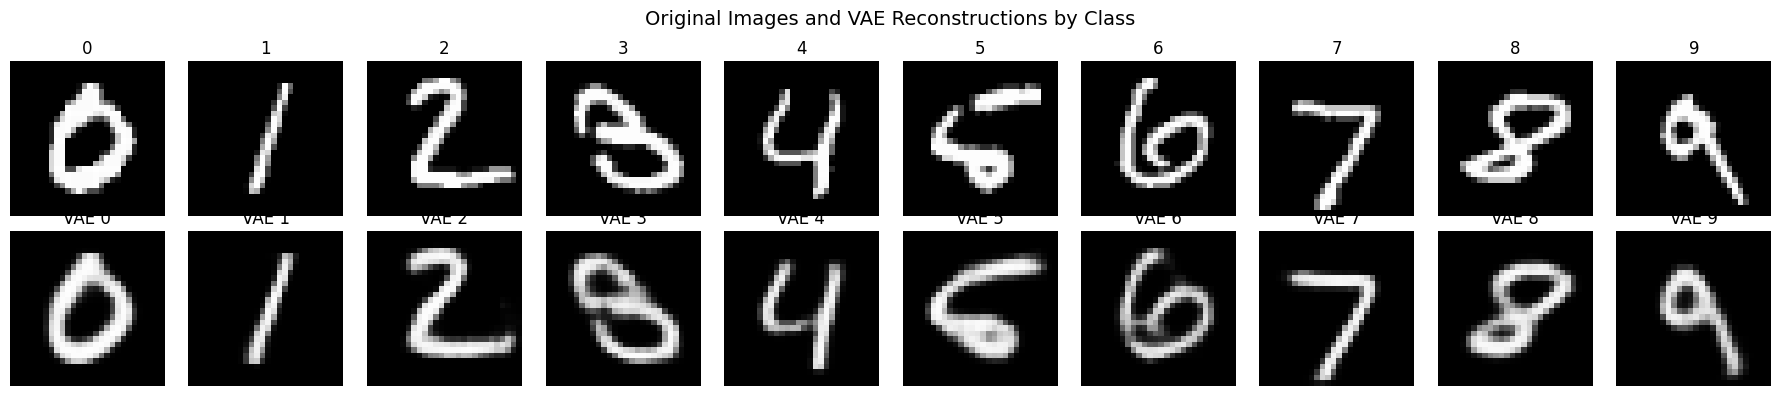

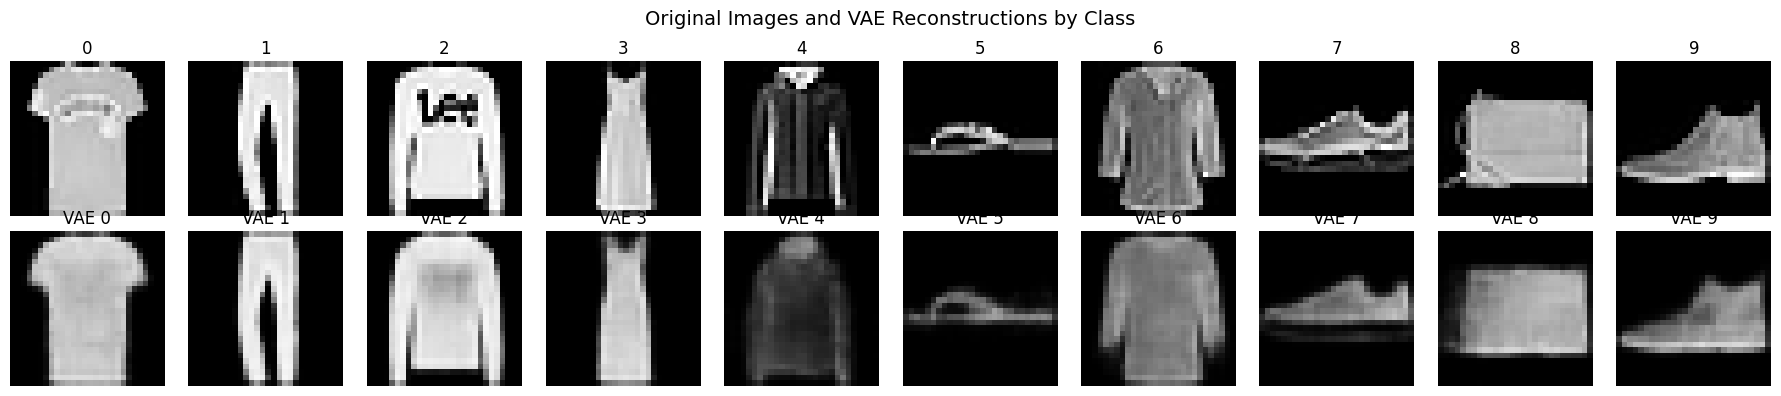

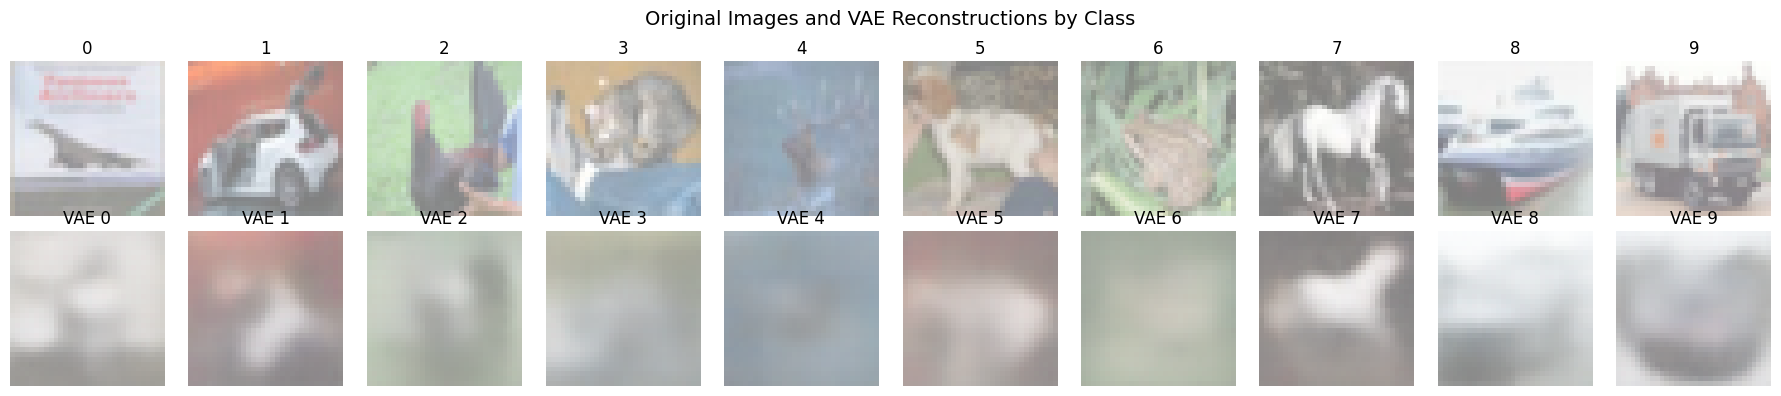

In [14]:
plot_vae_reconstructions_by_class(model=mnist_history_FP["model"], test_loader=mnist_test, device=device, num_classes=10, cmap='gray')
plot_vae_reconstructions_by_class(model=fmnist_history_FP["model"], test_loader=fashion_mnist_test, device=device, num_classes=10, cmap='gray')
plot_vae_reconstructions_by_class(model=cifar_history_FP["model"], test_loader=cifar10_test, device=device, num_classes=10, cmap=None)

In [15]:
print(getattr(cifar_history_FP["model"], 'dataset_name', '').lower())

cifar10


# Conv MP Training

## MNIST

In [16]:
# MNIST VAE Training
# 2. Instantiate the VAE model and send it to your device (CPU/GPU)
vae_net_mnist_mp = ConvVAE(
    in_channels=mnist_in_channels,     # 1
    input_size=mnist_input_size,       # (28, 28)
    latent_dim=LATENT_DIM,
    dataset_name="mnist"
).to(device)

# 3. Set up the optimizer 
# Adam with a learning rate of 1e-3 is the standard starting point for VAEs
vae_optimizer_mnist = optim.Adam(vae_net_mnist_mp.parameters(), lr=1e-3)

# 4. Set your test epochs
test_epochs = prod_EPOCHS #dev_EPOCHS

# 5. Run the training loop!
print(f"Starting VAE training for {test_epochs} epochs...")

mnist_history_MP = train_vae(
    model=vae_net_mnist_mp,
    train_loader=mnist_train,
    epochs=test_epochs,
    optimizer=vae_optimizer_mnist,
    device=device,
    dataset_name="mnist",
    use_mixed_precision=True  # Mixed Precision (FP16/FP32)
)

print("Test training complete!")

save_trained_vae(
    model=mnist_history_MP["model"],
    optimizer=mnist_history_MP["optimizer"],
    history=mnist_history_MP,
    save_dir="./saved_models/VAE/MNIST",
    run_name="vae_mnist_MP",
    model_config=mnist_config,
    extra_info={"dataset": "mnist", "precision": "mixed"}
)

Starting VAE training for 100 epochs...
Epoch [1/100] | Loss: 174.9043 | BCE: 148.9111 | KLD: 25.9933
Epoch [2/100] | Loss: 121.0587 | BCE: 90.2992 | KLD: 30.7595
Epoch [3/100] | Loss: 113.2625 | BCE: 83.4792 | KLD: 29.7833
Epoch [4/100] | Loss: 110.3407 | BCE: 81.0681 | KLD: 29.2727
Epoch [5/100] | Loss: 108.6076 | BCE: 79.7133 | KLD: 28.8944
Epoch [6/100] | Loss: 107.4623 | BCE: 78.7827 | KLD: 28.6796
Epoch [7/100] | Loss: 106.6018 | BCE: 78.0900 | KLD: 28.5118
Epoch [8/100] | Loss: 105.9287 | BCE: 77.5800 | KLD: 28.3487
Epoch [9/100] | Loss: 105.4289 | BCE: 77.1235 | KLD: 28.3054
Epoch [10/100] | Loss: 104.9941 | BCE: 76.8043 | KLD: 28.1899
Epoch [11/100] | Loss: 104.5637 | BCE: 76.5035 | KLD: 28.0602
Epoch [12/100] | Loss: 104.1742 | BCE: 76.2071 | KLD: 27.9671
Epoch [13/100] | Loss: 103.9193 | BCE: 76.0210 | KLD: 27.8983
Epoch [14/100] | Loss: 103.6136 | BCE: 75.8002 | KLD: 27.8134
Epoch [15/100] | Loss: 103.4289 | BCE: 75.6632 | KLD: 27.7657
Epoch [16/100] | Loss: 103.2529 | BCE:

('saved_models/VAE/MNIST/vae_mnist_MP.pt',
 'saved_models/VAE/MNIST/vae_mnist_MP_history.json')

## fMNIST

In [17]:
# Fashion MNIST VAE Training
# 2. Instantiate the VAE model and send it to your device (CPU/GPU)
vae_net_fmnist = ConvVAE(
    in_channels=fashion_mnist_in_channels,     # 1
    input_size=fashion_mnist_input_size,       # (28, 28)
    latent_dim=LATENT_DIM,
    dataset_name="fashion-mnist"
).to(device)

# 3. Set up the optimizer 
# Adam with a learning rate of 1e-3 is the standard starting point for VAEs
vae_optimizer_fmnist = optim.Adam(vae_net_fmnist.parameters(), lr=1e-3)

# 4. Set your test epochs
test_epochs = prod_EPOCHS#dev_EPOCHS

# 5. Run the training loop!
print(f"Starting VAE training for {test_epochs} epochs...")

fmnist_history_MP = train_vae(
    model=vae_net_fmnist,
    train_loader=fashion_mnist_train,
    epochs=test_epochs,
    optimizer=vae_optimizer_fmnist,
    device=device,
    dataset_name="fmnist",
    use_mixed_precision=True  # Mixed Precision (FP16/FP32)
)

print("Test training complete!")

save_trained_vae(
    model=fmnist_history_MP["model"],
    optimizer=fmnist_history_MP["optimizer"],
    history=fmnist_history_MP,
    save_dir="./saved_models/VAE/FMNIST",
    run_name="vae_fashionmnist_MP",
    model_config=fashion_mnist_config,
    extra_info={"dataset": "fashion-mnist", "precision": "mixed"}
)

Starting VAE training for 100 epochs...
Epoch [1/100] | Loss: 301.5245 | BCE: 280.3633 | KLD: 21.1611
Epoch [2/100] | Loss: 259.6456 | BCE: 239.5685 | KLD: 20.0771
Epoch [3/100] | Loss: 252.0705 | BCE: 233.0331 | KLD: 19.0374
Epoch [4/100] | Loss: 249.1850 | BCE: 230.4696 | KLD: 18.7154
Epoch [5/100] | Loss: 247.5790 | BCE: 229.0519 | KLD: 18.5272
Epoch [6/100] | Loss: 246.4126 | BCE: 227.9939 | KLD: 18.4187
Epoch [7/100] | Loss: 245.5412 | BCE: 227.1844 | KLD: 18.3568
Epoch [8/100] | Loss: 244.9102 | BCE: 226.6137 | KLD: 18.2965
Epoch [9/100] | Loss: 244.3003 | BCE: 226.0794 | KLD: 18.2209
Epoch [10/100] | Loss: 243.8667 | BCE: 225.6668 | KLD: 18.1998
Epoch [11/100] | Loss: 243.4495 | BCE: 225.2812 | KLD: 18.1684
Epoch [12/100] | Loss: 243.1159 | BCE: 224.9922 | KLD: 18.1238
Epoch [13/100] | Loss: 242.7608 | BCE: 224.7039 | KLD: 18.0569
Epoch [14/100] | Loss: 242.5709 | BCE: 224.4994 | KLD: 18.0715
Epoch [15/100] | Loss: 242.2775 | BCE: 224.2366 | KLD: 18.0409
Epoch [16/100] | Loss: 2

('saved_models/VAE/FMNIST/vae_fashionmnist_MP.pt',
 'saved_models/VAE/FMNIST/vae_fashionmnist_MP_history.json')

## Cifar-10

In [18]:
# cifar10 VAE Training
# 2. Instantiate the VAE model and send it to your device (CPU/GPU)
vae_net_cifar = ConvVAE(
    in_channels=cifar10_in_channels,   # 3
    input_size=cifar10_input_size,     # (32, 32)
    latent_dim=2*LATENT_DIM,                     # CIFAR needs a richer latent space
    dataset_name="cifar10"
).to(device)  
# 3. Set up the optimizer 
# Adam with a learning rate of 1e-3 is the standard starting point for VAEs
vae_cifar_optimizer = optim.Adam(vae_net_cifar.parameters(), lr=1e-3)
# 4. Set your test epochs
test_epochs = prod_EPOCHS #dev_EPOCHS
# 5. Run the training loop!
print(f"Starting VAE training for {test_epochs} epochs...")
cifar_history_MP = train_vae(
    model=vae_net_cifar,
    train_loader=cifar10_train,
    epochs=test_epochs,
    optimizer=vae_cifar_optimizer,
    device=device,
    dataset_name="cifar10",
    use_mixed_precision=True   # Enables modern AMP (FP16/FP32)
)
print("Test training complete!")

save_trained_vae(
    model=cifar_history_MP["model"],
    optimizer=cifar_history_MP["optimizer"],
    history=cifar_history_MP,
    save_dir="./saved_models/VAE/CIFAR",
    run_name="vae_cifar10_MP",
    model_config=cifar_config,
    extra_info={"dataset": "cifar10", "precision": "mixed"}
)

Starting VAE training for 100 epochs...
Epoch [1/100] | Loss: 185.4972 | BCE: 170.8065 | KLD: 14.6907
Epoch [2/100] | Loss: 87.3491 | BCE: 68.1923 | KLD: 19.1568
Epoch [3/100] | Loss: 82.6766 | BCE: 62.8307 | KLD: 19.8459
Epoch [4/100] | Loss: 80.9179 | BCE: 60.5670 | KLD: 20.3509
Epoch [5/100] | Loss: 79.8471 | BCE: 59.1771 | KLD: 20.6700
Epoch [6/100] | Loss: 78.9686 | BCE: 57.9492 | KLD: 21.0194
Epoch [7/100] | Loss: 78.3154 | BCE: 56.9776 | KLD: 21.3378
Epoch [8/100] | Loss: 77.9443 | BCE: 56.3810 | KLD: 21.5633
Epoch [9/100] | Loss: 77.5031 | BCE: 55.7628 | KLD: 21.7403
Epoch [10/100] | Loss: 77.2223 | BCE: 55.3472 | KLD: 21.8751
Epoch [11/100] | Loss: 77.0664 | BCE: 55.1183 | KLD: 21.9481
Epoch [12/100] | Loss: 76.7043 | BCE: 54.7264 | KLD: 21.9779
Epoch [13/100] | Loss: 76.6769 | BCE: 54.5996 | KLD: 22.0772
Epoch [14/100] | Loss: 76.4413 | BCE: 54.3337 | KLD: 22.1076
Epoch [15/100] | Loss: 76.3285 | BCE: 54.2114 | KLD: 22.1171
Epoch [16/100] | Loss: 76.2153 | BCE: 54.0420 | KLD:

('saved_models/VAE/CIFAR/vae_cifar10_MP.pt',
 'saved_models/VAE/CIFAR/vae_cifar10_MP_history.json')

## Plotting MP

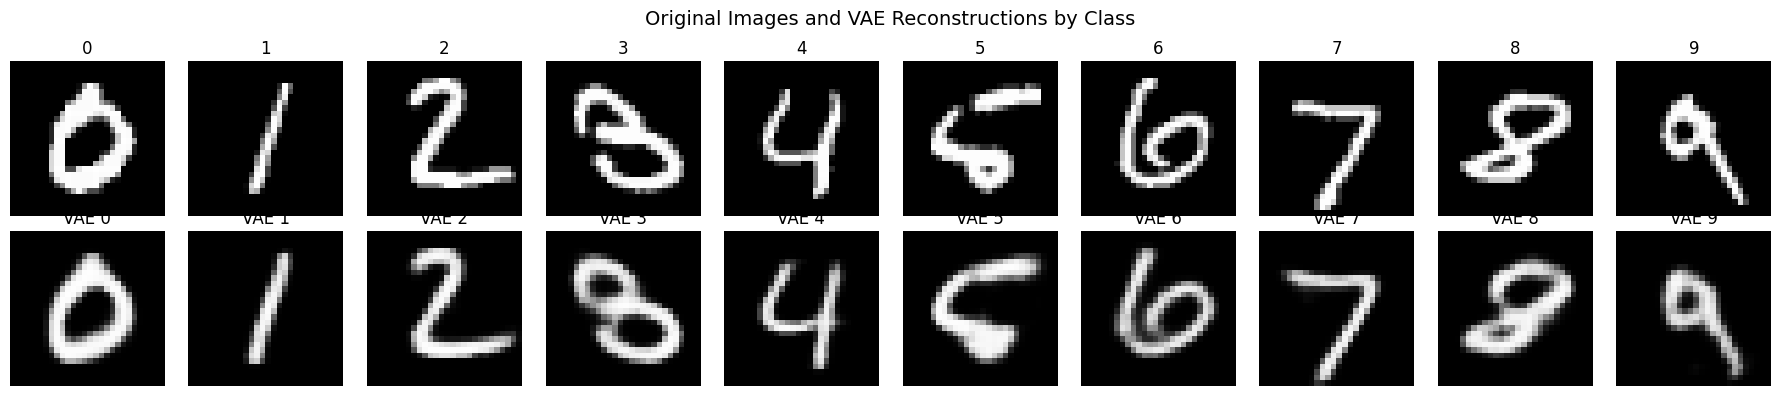

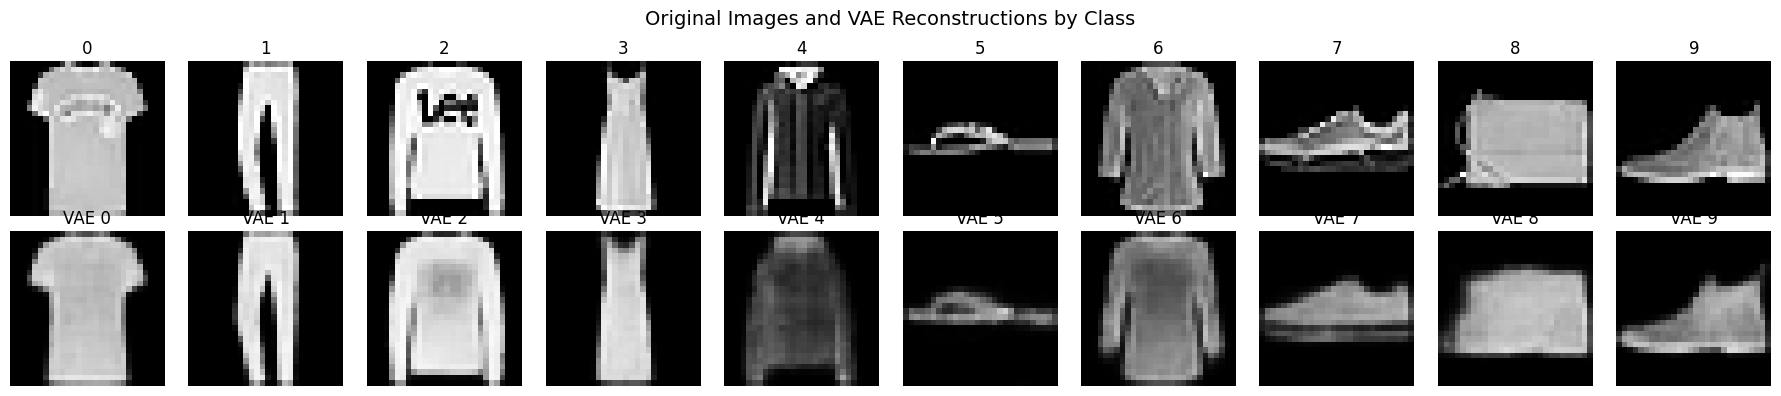

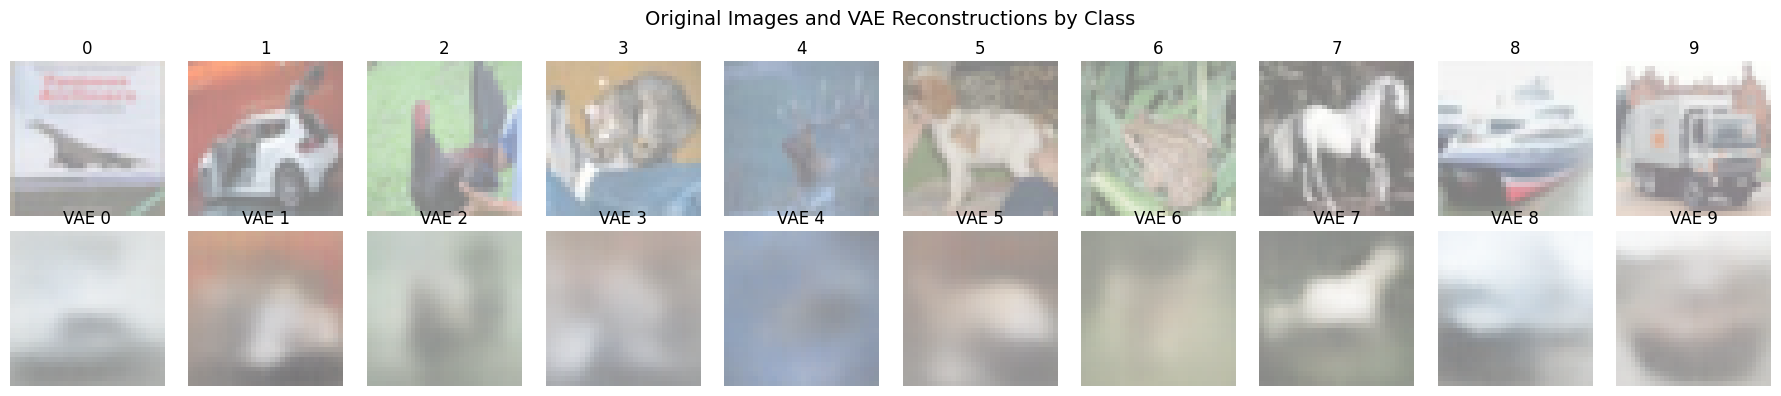

In [19]:
plot_vae_reconstructions_by_class(model=mnist_history_MP["model"], test_loader=mnist_test, device=device, num_classes=10, cmap='gray')
plot_vae_reconstructions_by_class(model=fmnist_history_MP["model"], test_loader=fashion_mnist_test, device=device, num_classes=10, cmap='gray')
plot_vae_reconstructions_by_class(model=cifar_history_MP["model"], test_loader=cifar10_test, device=device, num_classes=10, cmap=None)

In [20]:
print(getattr(cifar_history_MP["model"], 'dataset_name', '').lower())

cifar10


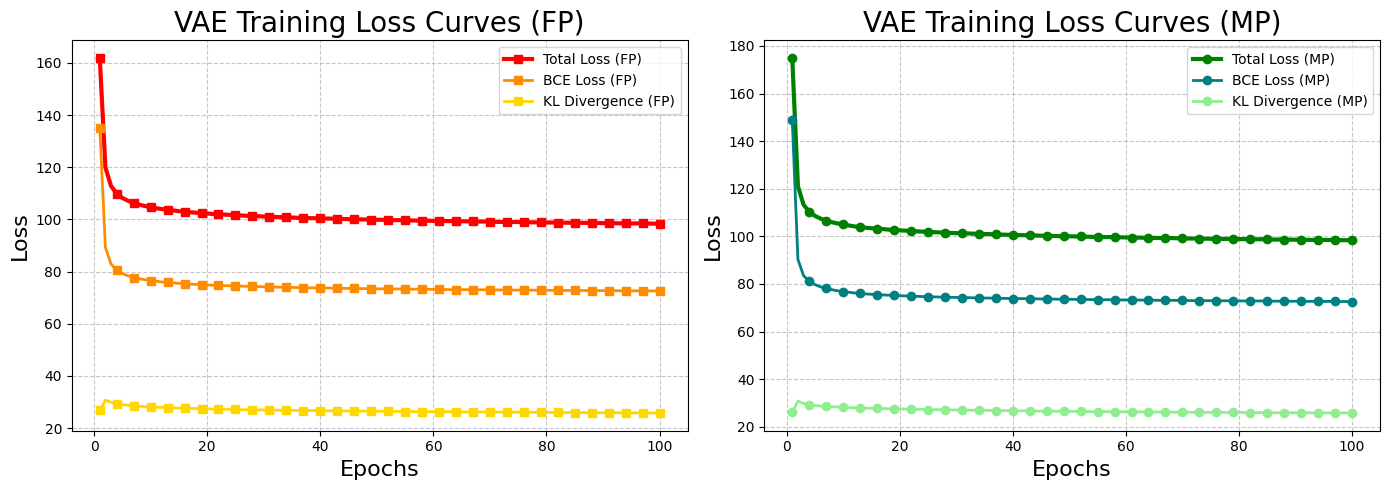

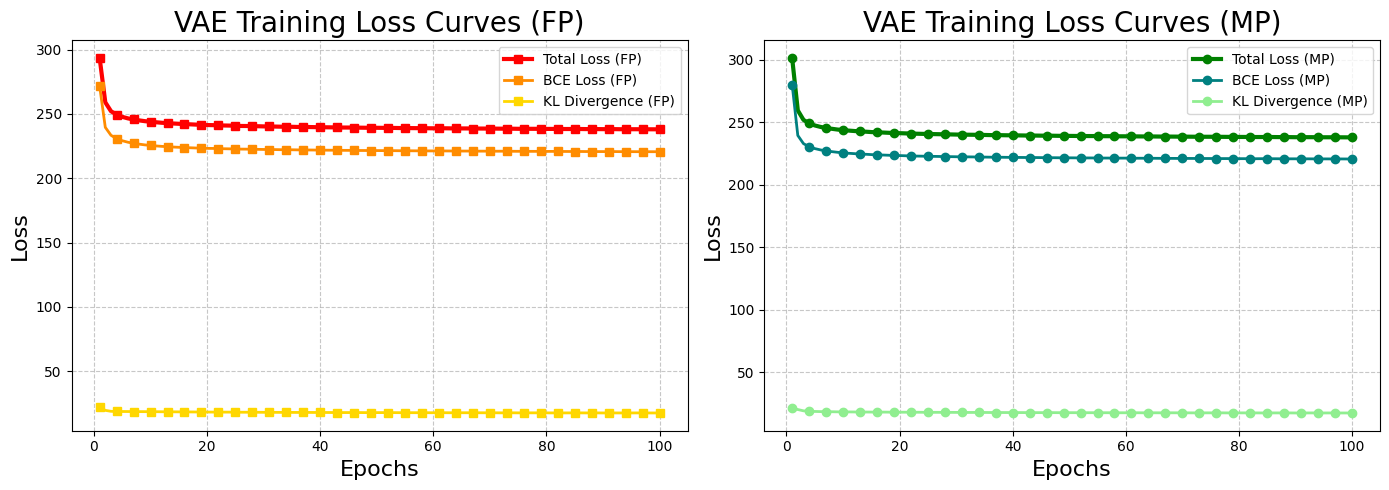

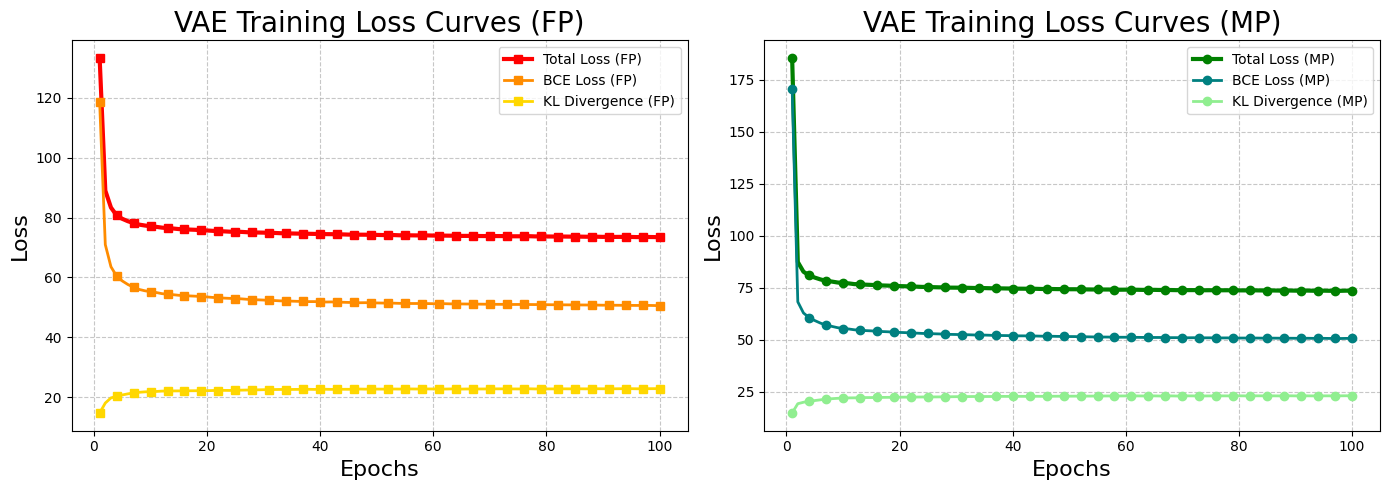

In [21]:
#plot_vae_history(MP, FP)
plot_vae_history(mnist_history_MP, mnist_history_FP)

plot_vae_history(fmnist_history_MP, fmnist_history_FP)

plot_vae_history(cifar_history_MP, cifar_history_FP)

# Linear CODE Implementation

In [40]:
class VAE(nn.Module):
    """
    Standard Variational Autoencoder using Linear (Fully Connected) layers.
    """
    def __init__(self, input_dim=784, hidden_channels=(512, 256), latent_dim=32, dataset_name="mnist"):
        super(VAE, self).__init__()
        
        self.input_dim = input_dim
        self.hidden_channels = hidden_channels
        self.latent_dim = latent_dim
        self.dataset_name = dataset_name.lower()

        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_channels[0]) #input to hidden
        self.enc_fc2 = nn.Linear(hidden_channels[0], hidden_channels[1]) #hidden to hidden

        # the encoder outputs the mean and log variance for the latent space
        self.enc_mean = nn.Linear(hidden_channels[1], latent_dim) #hidden to mean
        self.enc_logvar = nn.Linear(hidden_channels[1], latent_dim) #hidden to logvar

        # Decoder
        self.dec_fc1 = nn.Linear(latent_dim, hidden_channels[1]) #latent to hidden
        self.dec_fc2 = nn.Linear(hidden_channels[1], hidden_channels[0]) #hidden to hidden
        self.dec_output = nn.Linear(hidden_channels[0], input_dim) #hidden to output

        self.leaky_relu = nn.LeakyReLU(0.2) #LeakyReLU activation function


    def encode(self, x):
        """Encodes the input into the latent space, returning the mean and log variance."""
        h = self.leaky_relu(self.fc1(x))
        h = self.leaky_relu(self.enc_fc2(h))
        mean = self.enc_mean(h)
        logvar = self.enc_logvar(h)
        return mean, logvar
    
    def reparameterize(self, mean, logvar):
        """Applies reparameterization trick z = mean + std * eps, where eps ~ N(0, 1)
        This allows backpropagation through the stochastic sampling process."""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mean + std * eps
    

    def decode(self, z):
        """Decodes the latent variable back to the input space."""
        h = self.leaky_relu(self.dec_fc1(z))
        h = self.leaky_relu(self.dec_fc2(h))
        # tanh to get output in [-1, 1] (if CIFAR is normalized) or sigmoid for [0, 1] (if MNIST/Fashion)
        if self.dataset_name == "cifar10":
            x_hat = torch.tanh(self.dec_output(h))
        else:
            x_hat = torch.sigmoid(self.dec_output(h)) #sigmoid to get output in [0, 1]
        return x_hat
    
    def forward(self, x):
        # Flatten the input image to a vector
        BATCH_SIZE, C, H, W = x.size() #C = channels, H = height, W = width
        x_flat = x.view(BATCH_SIZE, -1) # Flatten the image to a vector

        # Encode the input to get mean and log variance
        mean, logvar = self.encode(x_flat)

        # Sample from the distribution using the reparameterization trick
        z = self.reparameterize(mean, logvar)

        # Decode the latent variable to reconstruct the input
        x_hat = self.decode(z)

        #reshape the output back to the original image shape
        x_hat = x_hat.view(BATCH_SIZE, C, H, W)
        return x_hat, mean, logvar

## Saved Model Loading Linear

In [14]:

### Linear models'
vae_checkpoint_path_linear = Path(str(KAGGLE_MODEL_DIR / "saved_models/VAE"))

vae_mnist_linear_fp = load_trained_vae(
    checkpoint_path=str(vae_checkpoint_path_linear/ "MNIST" / "vae_mnist_linear_FP.pt"),
    model_class=VAE,   # replace with your actual VAE class name
    device=device,
    load_best=True,            # set True if you want best_model_state_dict
)

vae_mnist_linear_mp = load_trained_vae(
    checkpoint_path=str(vae_checkpoint_path_linear/ "MNIST" / "vae_mnist_linear_MP.pt"),
    model_class=VAE,   # replace with your actual VAE class name
    device=device,
    load_best=True,            # set True if you want best_model_state_dict
)
vae_fmnist_linear_fp = load_trained_vae(
    checkpoint_path=str(vae_checkpoint_path_linear/ "FMNIST" / "vae_fashionmnist_linear_FP.pt"),
    model_class=VAE,   # replace with your actual VAE class name
    device=device,
    load_best=True,            # set True if you want best_model_state_dict
)

vae_fmnist_linear_mp = load_trained_vae(
    checkpoint_path=str(vae_checkpoint_path_linear/ "FMNIST" / "vae_fashionmnist_linear_MP.pt"),
    model_class=VAE,   # replace with your actual VAE class name
    device=device,
    load_best=True,            # set True if you want best_model_state_dict
)
vae_cifar10_linear_fp = load_trained_vae(
    checkpoint_path=str(vae_checkpoint_path_linear/ "CIFAR" / "vae_cifar10_linear_FP.pt"),
    model_class=VAE,   # replace with your actual VAE class name
    device=device,
    load_best=True,    # set True if you want best_model_state_dict
)
vae_cifar10_linear_mp = load_trained_vae(
    checkpoint_path=str(vae_checkpoint_path_linear/ "CIFAR" / "vae_cifar10_linear_MP.pt"),
    model_class=VAE,   # replace with your actual VAE class name
    device=device,
    load_best=True,    # set True if you want best_model_state_dict
)

# Linear FP Training

## MNIST Linear FP

In [23]:
# Linear MNIST VAE Training
# 2. Instantiate the VAE model and send it to your device (CPU/GPU)
vae_net_linear = VAE(
    input_dim=mnist_in_channels * mnist_input_size * mnist_input_size, # 1*28*28 = 784
    hidden_channels=hidden_channels,
    latent_dim=LATENT_DIM,
    dataset_name="mnist"
).to(device)

# 3. Set up the optimizer
vae_optimizer_linear = optim.Adam(vae_net_linear.parameters(), lr=1e-3)
# 4. Set your test epochs
test_epochs = prod_EPOCHS #dev_EPOCHS
# 5. Run the training loop!
print(f"Starting Linear VAE training for {test_epochs} epochs...")

mnist_history_linear_FP = train_vae(
    model=vae_net_linear,
    train_loader=mnist_train,
    epochs=test_epochs,
    optimizer=vae_optimizer_linear,
    device=device,
    dataset_name="mnist",
    use_mixed_precision=False  # Standard FP32
)
print("Linear VAE training complete!")

save_trained_vae(
    model=mnist_history_linear_FP["model"],
    optimizer=mnist_history_linear_FP["optimizer"],
    history=mnist_history_linear_FP,
    save_dir="./saved_models/VAE/MNIST",
    run_name="vae_mnist_linear_FP",
    model_config=mnist_config,
    extra_info={"dataset": "mnist", "precision": "fp32"}
)

Starting Linear VAE training for 100 epochs...
Epoch [1/100] | Loss: 546.0577 | BCE: 545.7742 | KLD: 0.2835
Epoch [2/100] | Loss: 543.4177 | BCE: 543.4157 | KLD: 0.0020
Epoch [3/100] | Loss: 543.4173 | BCE: 543.4143 | KLD: 0.0030
Epoch [4/100] | Loss: 543.4037 | BCE: 543.3596 | KLD: 0.0441
Epoch [5/100] | Loss: 543.2823 | BCE: 543.0044 | KLD: 0.2779
Epoch [6/100] | Loss: 543.0783 | BCE: 542.6034 | KLD: 0.4749
Epoch [7/100] | Loss: 543.0007 | BCE: 542.5060 | KLD: 0.4948
Epoch [8/100] | Loss: 542.9830 | BCE: 542.4633 | KLD: 0.5197
Epoch [9/100] | Loss: 542.8757 | BCE: 542.0787 | KLD: 0.7970
Epoch [10/100] | Loss: 542.4827 | BCE: 541.3963 | KLD: 1.0864
Epoch [11/100] | Loss: 542.0559 | BCE: 540.5074 | KLD: 1.5484
Epoch [12/100] | Loss: 541.7349 | BCE: 539.9352 | KLD: 1.7997
Epoch [13/100] | Loss: 541.3337 | BCE: 539.2083 | KLD: 2.1254
Epoch [14/100] | Loss: 541.0068 | BCE: 538.5779 | KLD: 2.4289
Epoch [15/100] | Loss: 540.6993 | BCE: 537.9570 | KLD: 2.7423
Epoch [16/100] | Loss: 540.3952 

('saved_models/VAE/MNIST/vae_mnist_linear_FP.pt',
 'saved_models/VAE/MNIST/vae_mnist_linear_FP_history.json')

## FMNIST Linear FP

In [24]:
# Linear Fashion MNIST VAE Training
# 2. Instantiate the VAE model and send it to your device (CPU/GPU)
vae_net_fmnist_linear = VAE(
    input_dim=fashion_mnist_in_channels * fashion_mnist_input_size * fashion_mnist_input_size, # 1*28*28 = 784
    hidden_channels=hidden_channels,
    latent_dim=LATENT_DIM,
    dataset_name="fashion-mnist"
).to(device)
# 3. Set up the optimizer
vae_optimizer_fmnist_linear = optim.Adam(vae_net_fmnist_linear.parameters(), lr=1e-3)
# 4. Set your test epochs
test_epochs = prod_EPOCHS #dev_EPOCHS
# 5. Run the training loop!
print(f"Starting Linear VAE training for {test_epochs} epochs...")

fmnist_history_linear_FP = train_vae(
    model=vae_net_fmnist_linear,
    train_loader=fashion_mnist_train,
    epochs=test_epochs,
    optimizer=vae_optimizer_fmnist_linear,
    device=device,
    dataset_name="fashion-mnist",
    use_mixed_precision=False  # Standard FP32
)
print("Linear VAE training complete!")

save_trained_vae(
    model=fmnist_history_linear_FP["model"],
    optimizer=fmnist_history_linear_FP["optimizer"],
    history=fmnist_history_linear_FP,
    save_dir="./saved_models/VAE/FMNIST",
    run_name="vae_fashionmnist_linear_FP",
    model_config=fashion_mnist_config,
    extra_info={"dataset": "fashion-mnist", "precision": "fp32"}
)

Starting Linear VAE training for 100 epochs...
Epoch [1/100] | Loss: 536.8028 | BCE: 534.6847 | KLD: 2.1181
Epoch [2/100] | Loss: 529.8382 | BCE: 526.3228 | KLD: 3.5154
Epoch [3/100] | Loss: 527.0968 | BCE: 523.6202 | KLD: 3.4767
Epoch [4/100] | Loss: 524.8780 | BCE: 521.3226 | KLD: 3.5554
Epoch [5/100] | Loss: 524.1087 | BCE: 520.3703 | KLD: 3.7384
Epoch [6/100] | Loss: 523.7228 | BCE: 519.8783 | KLD: 3.8445
Epoch [7/100] | Loss: 523.2718 | BCE: 519.3250 | KLD: 3.9467
Epoch [8/100] | Loss: 522.7461 | BCE: 518.6786 | KLD: 4.0675
Epoch [9/100] | Loss: 522.3192 | BCE: 518.1726 | KLD: 4.1466
Epoch [10/100] | Loss: 522.1767 | BCE: 517.9549 | KLD: 4.2218
Epoch [11/100] | Loss: 522.0168 | BCE: 517.7825 | KLD: 4.2343
Epoch [12/100] | Loss: 521.8945 | BCE: 517.6336 | KLD: 4.2610
Epoch [13/100] | Loss: 521.7893 | BCE: 517.5051 | KLD: 4.2842
Epoch [14/100] | Loss: 521.7328 | BCE: 517.4181 | KLD: 4.3147
Epoch [15/100] | Loss: 521.6611 | BCE: 517.3050 | KLD: 4.3560
Epoch [16/100] | Loss: 521.5533 

('saved_models/VAE/FMNIST/vae_fashionmnist_linear_FP.pt',
 'saved_models/VAE/FMNIST/vae_fashionmnist_linear_FP_history.json')

## Cifar Linear FP

In [25]:
# Linear Cifar10 VAE Training
# 2. Instantiate the VAE model and send it to your device (CPU/GPU)
vae_net_cifar_linear = VAE(
    input_dim=cifar10_in_channels * cifar10_input_size * cifar10_input_size, # 3*32*32 = 3072
    hidden_channels=hidden_channels,
    latent_dim=4*LATENT_DIM,                     # CIFAR needs a richer latent space
    dataset_name="cifar10"
).to(device)
# 3. Set up the optimizer
vae_optimizer_cifar_linear = optim.Adam(vae_net_cifar_linear.parameters(), lr=1e-3)
# 4. Set your test epochs
test_epochs = prod_EPOCHS #dev_EPOCHS
# 5. Run the training loop!
print(f"Starting Linear VAE training for {test_epochs} epochs...")
cifar_history_linear_FP = train_vae(
    model=vae_net_cifar_linear,
    train_loader=cifar10_train,
    epochs=test_epochs,
    optimizer=vae_optimizer_cifar_linear,
    device=device,
    dataset_name="cifar10",
    use_mixed_precision=False   # Enables modern AMP (FP16/FP32)
)   
print("Linear VAE training complete!")

save_trained_vae(
    model=cifar_history_linear_FP["model"],
    optimizer=cifar_history_linear_FP["optimizer"],
    history=cifar_history_linear_FP,
    save_dir="./saved_models/VAE/CIFAR",
    run_name="vae_cifar10_linear_FP",
    model_config=cifar_config,
    extra_info={"dataset": "cifar10", "precision": "fp32"}
)

Starting Linear VAE training for 100 epochs...
Epoch [1/100] | Loss: 154.2733 | BCE: 142.9797 | KLD: 11.2936
Epoch [2/100] | Loss: 121.9122 | BCE: 108.8416 | KLD: 13.0706
Epoch [3/100] | Loss: 106.6891 | BCE: 92.7506 | KLD: 13.9386
Epoch [4/100] | Loss: 99.4633 | BCE: 85.8953 | KLD: 13.5680
Epoch [5/100] | Loss: 97.1788 | BCE: 83.1958 | KLD: 13.9830
Epoch [6/100] | Loss: 92.5614 | BCE: 78.1501 | KLD: 14.4113
Epoch [7/100] | Loss: 89.9064 | BCE: 75.3818 | KLD: 14.5246
Epoch [8/100] | Loss: 88.7487 | BCE: 73.5983 | KLD: 15.1503
Epoch [9/100] | Loss: 87.8704 | BCE: 72.2597 | KLD: 15.6107
Epoch [10/100] | Loss: 86.6175 | BCE: 70.7275 | KLD: 15.8901
Epoch [11/100] | Loss: 85.8399 | BCE: 69.6981 | KLD: 16.1418
Epoch [12/100] | Loss: 84.8648 | BCE: 68.5642 | KLD: 16.3006
Epoch [13/100] | Loss: 84.7968 | BCE: 68.2267 | KLD: 16.5701
Epoch [14/100] | Loss: 83.7075 | BCE: 66.9433 | KLD: 16.7642
Epoch [15/100] | Loss: 83.2261 | BCE: 66.3454 | KLD: 16.8807
Epoch [16/100] | Loss: 83.0461 | BCE: 66.1

('saved_models/VAE/CIFAR/vae_cifar10_linear_FP.pt',
 'saved_models/VAE/CIFAR/vae_cifar10_linear_FP_history.json')

## Plotting linear FP results

hoi


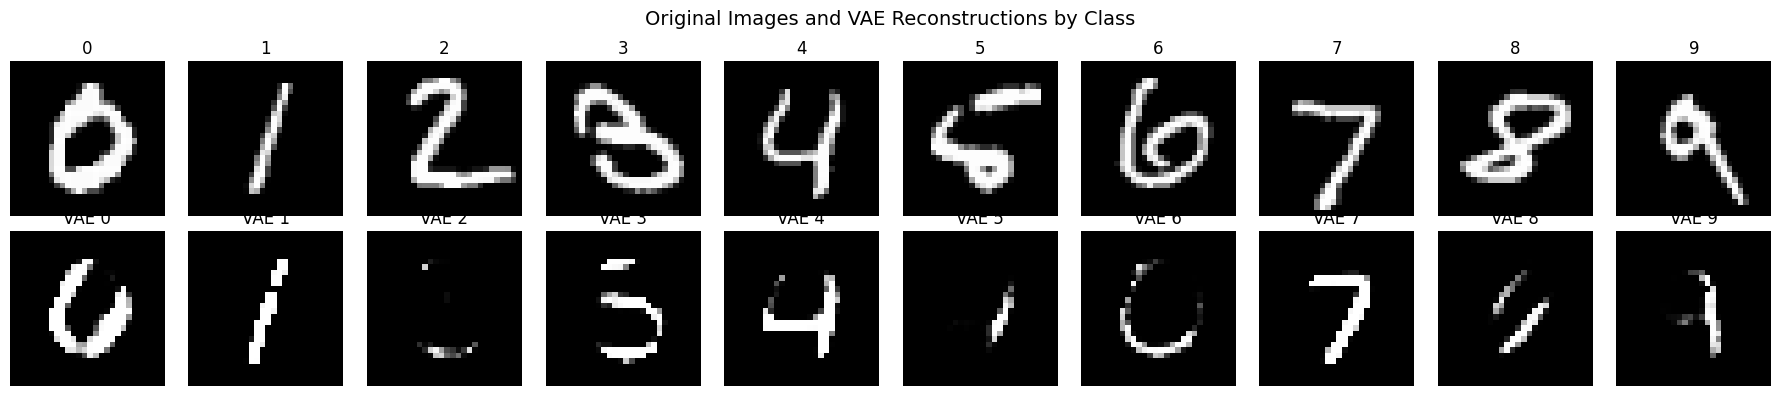

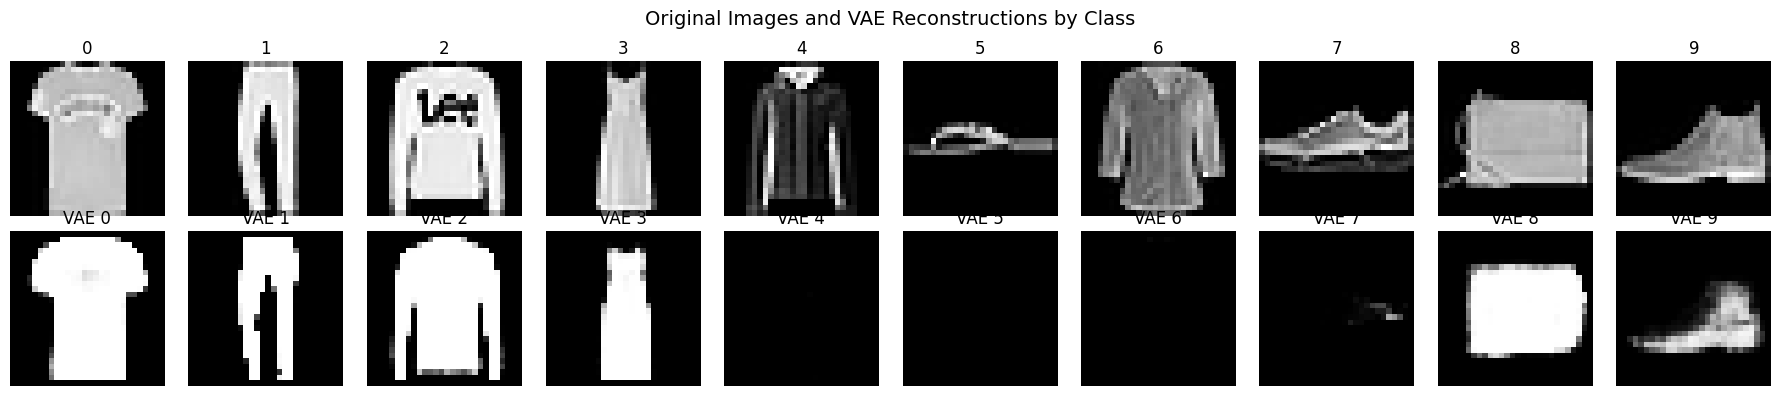

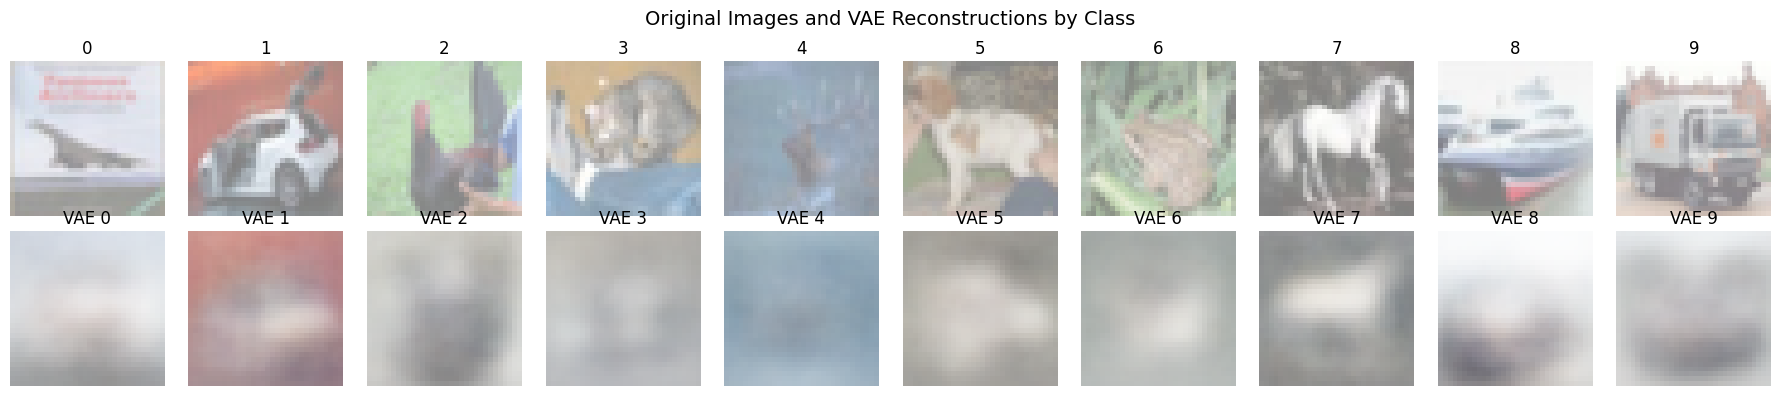

In [26]:
print("hoi")
plot_vae_reconstructions_by_class(model=mnist_history_linear_FP["model"], test_loader=mnist_test, device=device, num_classes=10, cmap='gray')
plot_vae_reconstructions_by_class(model=fmnist_history_linear_FP["model"], test_loader=fashion_mnist_test, device=device, num_classes=10, cmap='gray')
plot_vae_reconstructions_by_class(model=cifar_history_linear_FP["model"], test_loader=cifar10_test, device=device, num_classes=10, cmap=None)


# Linear MP Training

## Linear MNIST MP

In [27]:
# Linear MNIST VAE Training
# 2. Instantiate the VAE model and send it to your device (CPU/GPU)
vae_net_linear = VAE(
    input_dim=mnist_in_channels * mnist_input_size * mnist_input_size, # 1*28*28 = 784
    hidden_channels=hidden_channels,
    latent_dim=LATENT_DIM,
    dataset_name="mnist"
).to(device)

# 3. Set up the optimizer
vae_optimizer_linear = optim.Adam(vae_net_linear.parameters(), lr=1e-3)
# 4. Set your test epochs
test_epochs = prod_EPOCHS #dev_EPOCHS
# 5. Run the training loop!
print(f"Starting Linear VAE training for {test_epochs} epochs...")

mnist_history_linear_MP = train_vae(
    model=vae_net_linear,
    train_loader=mnist_train,
    epochs=test_epochs,
    optimizer=vae_optimizer_linear,
    device=device,
    dataset_name="mnist",
    use_mixed_precision=True  # Standard FP32
)
print("Linear VAE training complete!")

save_trained_vae(
    model=mnist_history_linear_MP["model"],
    optimizer=mnist_history_linear_MP["optimizer"],
    history=mnist_history_linear_MP,
    save_dir="./saved_models/VAE/MNIST",
    run_name="vae_mnist_linear_MP",
    model_config=mnist_config,
    extra_info={"dataset": "mnist", "precision": "mixed"}
)

Starting Linear VAE training for 100 epochs...
Epoch [1/100] | Loss: 548.7858 | BCE: 548.4703 | KLD: 0.3155
Epoch [2/100] | Loss: 543.4189 | BCE: 543.4170 | KLD: 0.0019
Epoch [3/100] | Loss: 543.4183 | BCE: 543.4158 | KLD: 0.0025
Epoch [4/100] | Loss: 543.4011 | BCE: 543.3668 | KLD: 0.0343
Epoch [5/100] | Loss: 543.3264 | BCE: 543.1140 | KLD: 0.2124
Epoch [6/100] | Loss: 543.2042 | BCE: 542.8474 | KLD: 0.3568
Epoch [7/100] | Loss: 543.0716 | BCE: 542.6002 | KLD: 0.4714
Epoch [8/100] | Loss: 543.0168 | BCE: 542.5112 | KLD: 0.5056
Epoch [9/100] | Loss: 542.9668 | BCE: 542.3629 | KLD: 0.6039
Epoch [10/100] | Loss: 542.7771 | BCE: 541.7532 | KLD: 1.0239
Epoch [11/100] | Loss: 542.3805 | BCE: 540.9249 | KLD: 1.4556
Epoch [12/100] | Loss: 542.1694 | BCE: 540.4792 | KLD: 1.6902
Epoch [13/100] | Loss: 541.7901 | BCE: 539.7595 | KLD: 2.0307
Epoch [14/100] | Loss: 541.4090 | BCE: 539.1233 | KLD: 2.2857
Epoch [15/100] | Loss: 540.9246 | BCE: 538.2818 | KLD: 2.6427
Epoch [16/100] | Loss: 540.6456 

('saved_models/VAE/MNIST/vae_mnist_linear_MP.pt',
 'saved_models/VAE/MNIST/vae_mnist_linear_MP_history.json')

## Linear FMNIST MP

In [28]:
# Linear Fashion MNIST VAE Training
# 2. Instantiate the VAE model and send it to your device (CPU/GPU)
vae_net_fmnist_linear = VAE(
    input_dim=fashion_mnist_in_channels * fashion_mnist_input_size * fashion_mnist_input_size, # 1*28*28 = 784
    hidden_channels=hidden_channels,
    latent_dim=LATENT_DIM,
    dataset_name="fashion-mnist"
).to(device)
# 3. Set up the optimizer
vae_optimizer_fmnist_linear = optim.Adam(vae_net_fmnist_linear.parameters(), lr=1e-3)
# 4. Set your test epochs
test_epochs = prod_EPOCHS #dev_EPOCHS
# 5. Run the training loop!
print(f"Starting Linear VAE training for {test_epochs} epochs...")

fmnist_history_linear_MP = train_vae(
    model=vae_net_fmnist_linear,
    train_loader=fashion_mnist_train,
    epochs=test_epochs,
    optimizer=vae_optimizer_fmnist_linear,
    device=device,
    dataset_name="fashion-mnist",
    use_mixed_precision=True  
)
print("Linear VAE training complete!")

save_trained_vae(
    model=fmnist_history_linear_MP["model"],
    optimizer=fmnist_history_linear_MP["optimizer"],
    history=fmnist_history_linear_MP,
    save_dir="./saved_models/VAE/FMNIST",
    run_name="vae_fashionmnist_linear_MP",
    model_config=fashion_mnist_config,
    extra_info={"dataset": "fashion-mnist", "precision": "mixed"}
)

Starting Linear VAE training for 100 epochs...
Epoch [1/100] | Loss: 538.6256 | BCE: 536.5921 | KLD: 2.0335
Epoch [2/100] | Loss: 529.7691 | BCE: 526.2690 | KLD: 3.5001
Epoch [3/100] | Loss: 527.6436 | BCE: 524.0409 | KLD: 3.6027
Epoch [4/100] | Loss: 525.0962 | BCE: 521.4630 | KLD: 3.6332
Epoch [5/100] | Loss: 523.8789 | BCE: 520.0312 | KLD: 3.8476
Epoch [6/100] | Loss: 523.0179 | BCE: 518.9960 | KLD: 4.0219
Epoch [7/100] | Loss: 522.4809 | BCE: 518.3555 | KLD: 4.1254
Epoch [8/100] | Loss: 522.0942 | BCE: 517.8914 | KLD: 4.2027
Epoch [9/100] | Loss: 521.9256 | BCE: 517.6518 | KLD: 4.2738
Epoch [10/100] | Loss: 521.8047 | BCE: 517.4726 | KLD: 4.3321
Epoch [11/100] | Loss: 521.6537 | BCE: 517.2843 | KLD: 4.3694
Epoch [12/100] | Loss: 521.5000 | BCE: 517.0965 | KLD: 4.4035
Epoch [13/100] | Loss: 521.4374 | BCE: 517.0044 | KLD: 4.4331
Epoch [14/100] | Loss: 521.3760 | BCE: 516.9199 | KLD: 4.4561
Epoch [15/100] | Loss: 521.2908 | BCE: 516.8260 | KLD: 4.4648
Epoch [16/100] | Loss: 521.1573 

('saved_models/VAE/FMNIST/vae_fashionmnist_linear_MP.pt',
 'saved_models/VAE/FMNIST/vae_fashionmnist_linear_MP_history.json')

## Linear Cifar-10 MP

In [29]:
# Linear Cifar10 VAE Training
# 2. Instantiate the VAE model and send it to your device (CPU/GPU)
vae_net_cifar_linear = VAE(
    input_dim=cifar10_in_channels * cifar10_input_size * cifar10_input_size, # 3*32*32 = 3072
    hidden_channels=hidden_channels,
    latent_dim=4*LATENT_DIM,                     # CIFAR needs a richer latent space
    dataset_name="cifar10"
).to(device)
# 3. Set up the optimizer
vae_optimizer_cifar_linear = optim.Adam(vae_net_cifar_linear.parameters(), lr=1e-3)
# 4. Set your test epochs
test_epochs = prod_EPOCHS #dev_EPOCHS
# 5. Run the training loop!
print(f"Starting Linear VAE training for {test_epochs} epochs...")
cifar_history_linear_MP = train_vae(
    model=vae_net_cifar_linear,
    train_loader=cifar10_train,
    epochs=test_epochs,
    optimizer=vae_optimizer_cifar_linear,
    device=device,
    dataset_name="cifar10",
    use_mixed_precision=True   # Enables modern AMP (FP16/FP32)
)   
print("Linear VAE training complete!")

save_trained_vae(
    model=cifar_history_linear_MP["model"],
    optimizer=cifar_history_linear_MP["optimizer"],
    history=cifar_history_linear_MP,
    save_dir="./saved_models/VAE/CIFAR",
    run_name="vae_cifar10_linear_MP",
    model_config=cifar_config,
    extra_info={"dataset": "cifar10", "precision": "mixed"}
)

Starting Linear VAE training for 100 epochs...
Epoch [1/100] | Loss: 177.8307 | BCE: 165.9128 | KLD: 11.9179
Epoch [2/100] | Loss: 123.5464 | BCE: 110.6832 | KLD: 12.8632
Epoch [3/100] | Loss: 111.8638 | BCE: 97.1739 | KLD: 14.6899
Epoch [4/100] | Loss: 103.8663 | BCE: 89.3307 | KLD: 14.5356
Epoch [5/100] | Loss: 97.7024 | BCE: 83.3364 | KLD: 14.3660
Epoch [6/100] | Loss: 91.6920 | BCE: 77.3490 | KLD: 14.3430
Epoch [7/100] | Loss: 88.8191 | BCE: 74.3034 | KLD: 14.5157
Epoch [8/100] | Loss: 87.5809 | BCE: 72.4081 | KLD: 15.1728
Epoch [9/100] | Loss: 85.9838 | BCE: 70.4637 | KLD: 15.5201
Epoch [10/100] | Loss: 85.2767 | BCE: 69.4548 | KLD: 15.8220
Epoch [11/100] | Loss: 85.0443 | BCE: 68.8865 | KLD: 16.1578
Epoch [12/100] | Loss: 84.5103 | BCE: 68.0527 | KLD: 16.4576
Epoch [13/100] | Loss: 84.2974 | BCE: 67.6882 | KLD: 16.6092
Epoch [14/100] | Loss: 83.7635 | BCE: 67.0277 | KLD: 16.7358
Epoch [15/100] | Loss: 83.1723 | BCE: 66.2678 | KLD: 16.9045
Epoch [16/100] | Loss: 82.7512 | BCE: 65.

('saved_models/VAE/CIFAR/vae_cifar10_linear_MP.pt',
 'saved_models/VAE/CIFAR/vae_cifar10_linear_MP_history.json')

## Plotting Linear MP

In [25]:
plot_vae_reconstructions_by_class(model=mnist_history_linear_MP["model"], test_loader=mnist_test, device=device, num_classes=10, cmap='gray')
plot_vae_reconstructions_by_class(model=fmnist_history_linear_MP["model"], test_loader=fashion_mnist_test, device=device, num_classes=10, cmap='gray')
plot_vae_reconstructions_by_class(model=cifar_history_linear_MP["model"], test_loader=cifar10_test, device=device, num_classes=10, cmap=None)

NameError: name 'mnist_history_linear_MP' is not defined

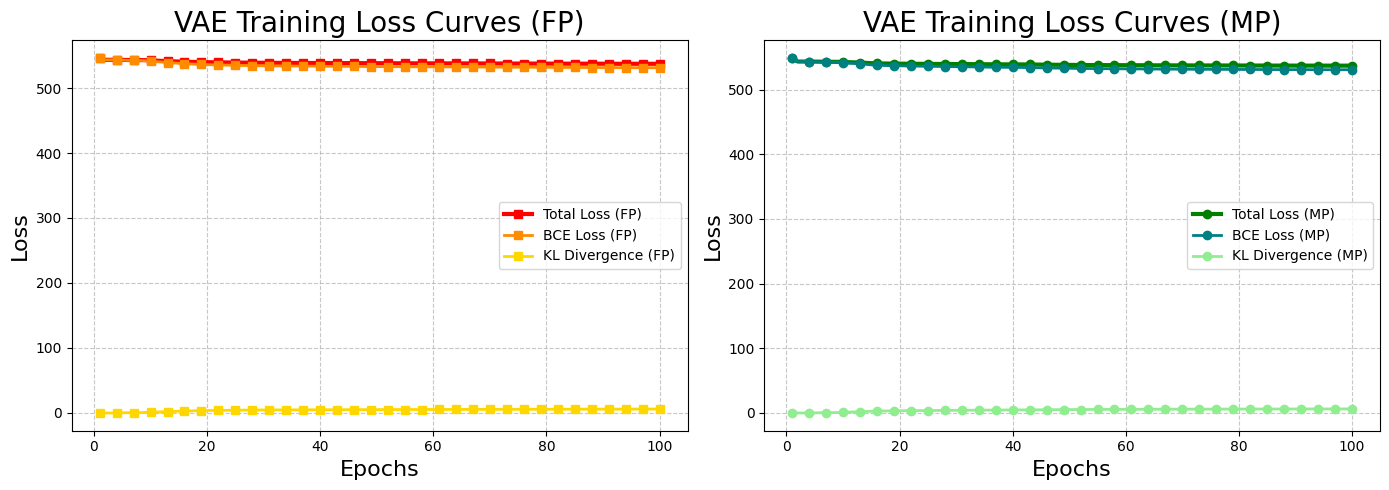

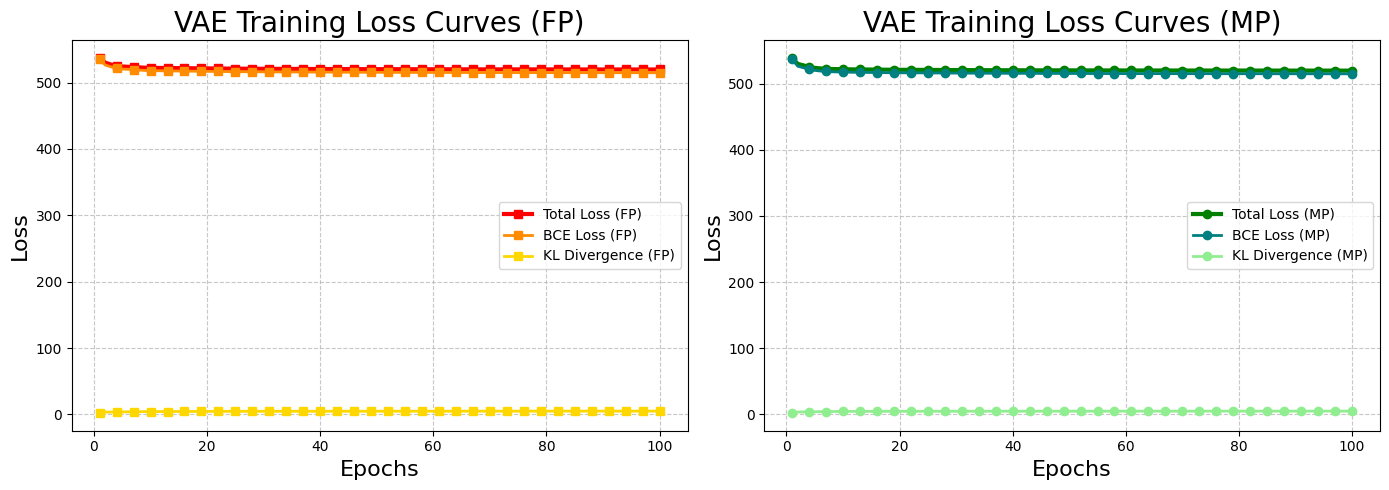

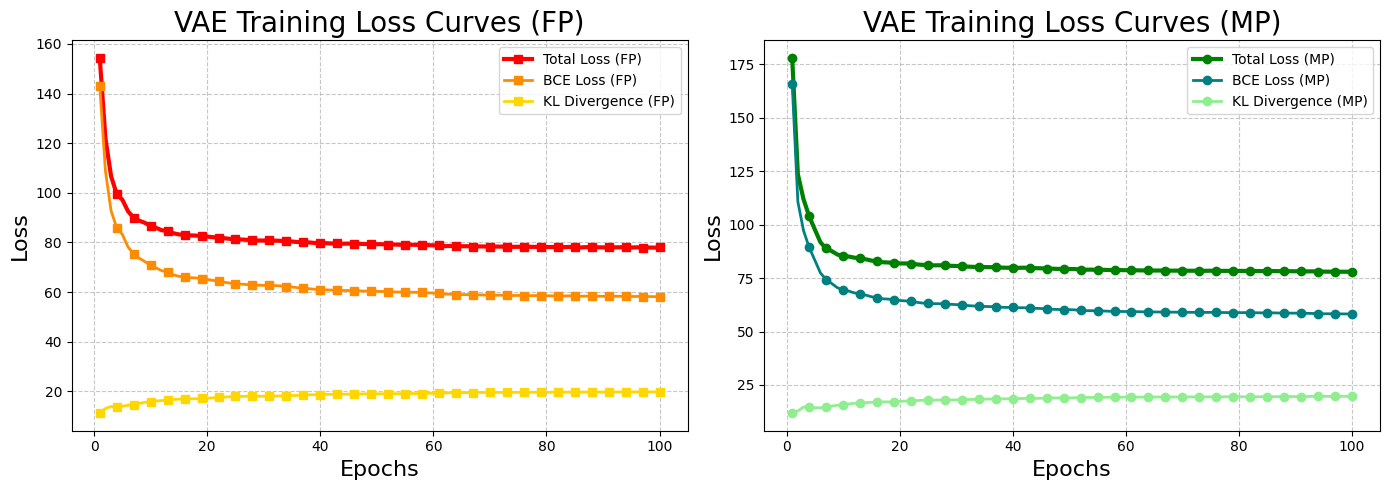

In [31]:
#plot_vae_history(MP, FP)
plot_vae_history(mnist_history_linear_MP, mnist_history_linear_FP)

plot_vae_history(fmnist_history_linear_MP, fmnist_history_linear_FP)

plot_vae_history(cifar_history_linear_MP, cifar_history_linear_FP)

# Analysis and graphs

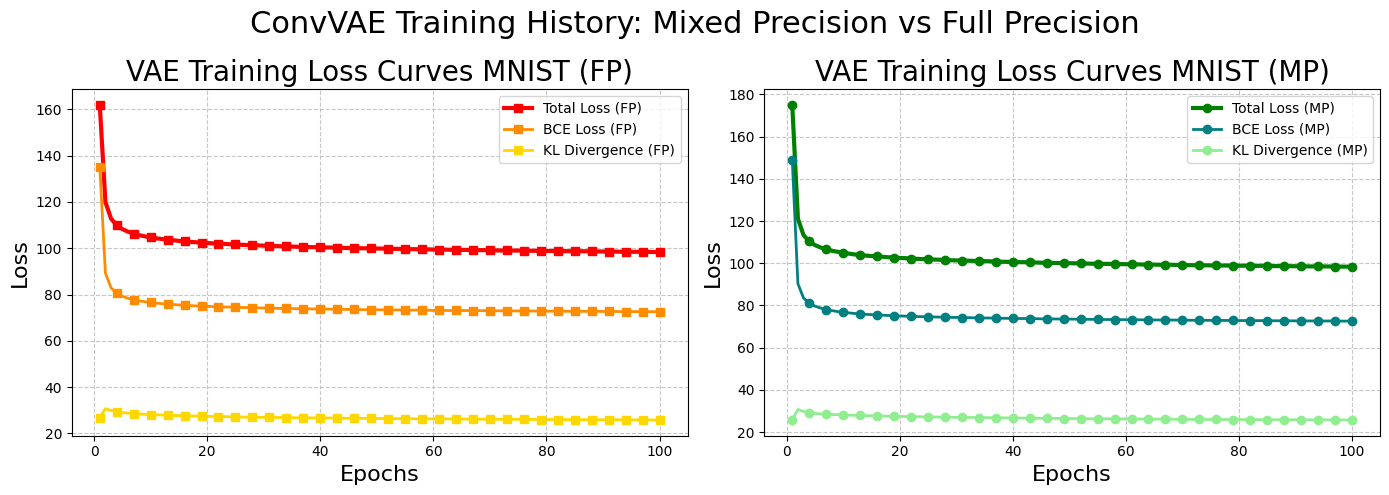

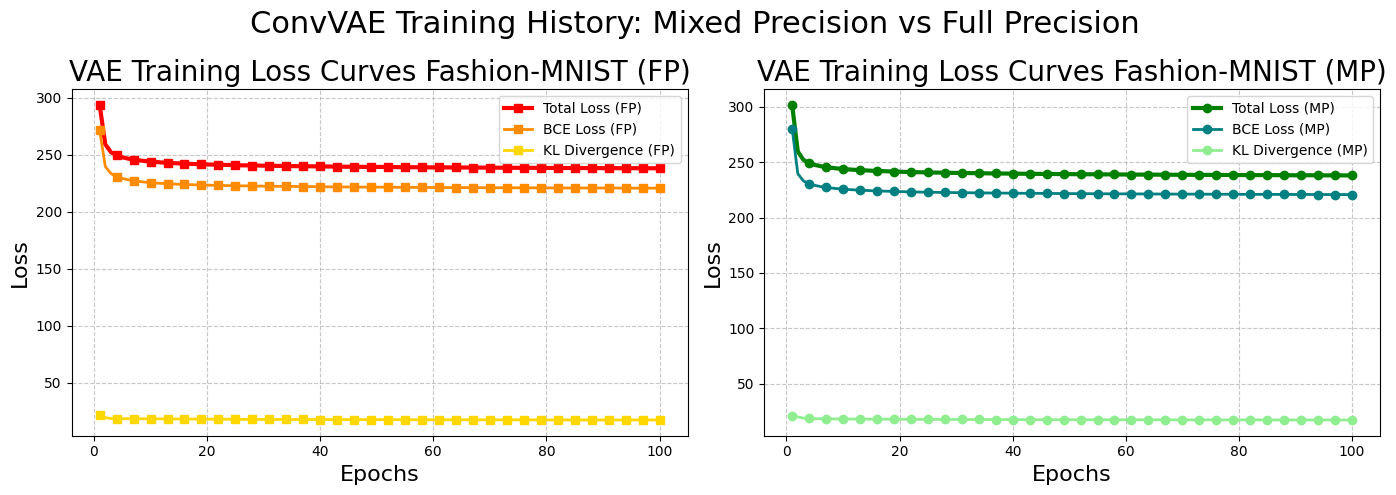

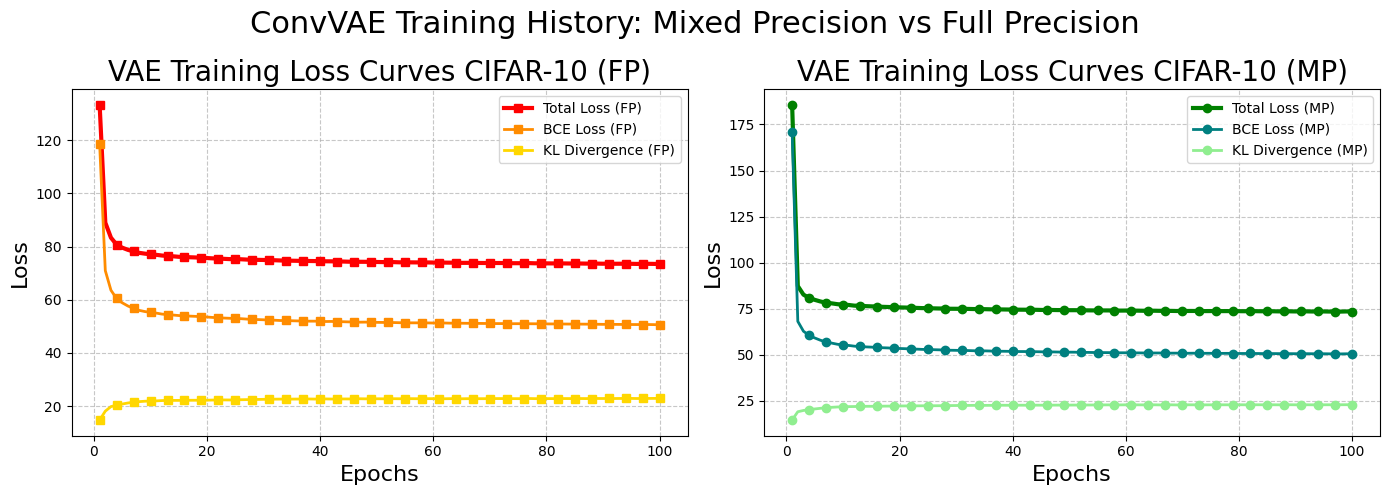

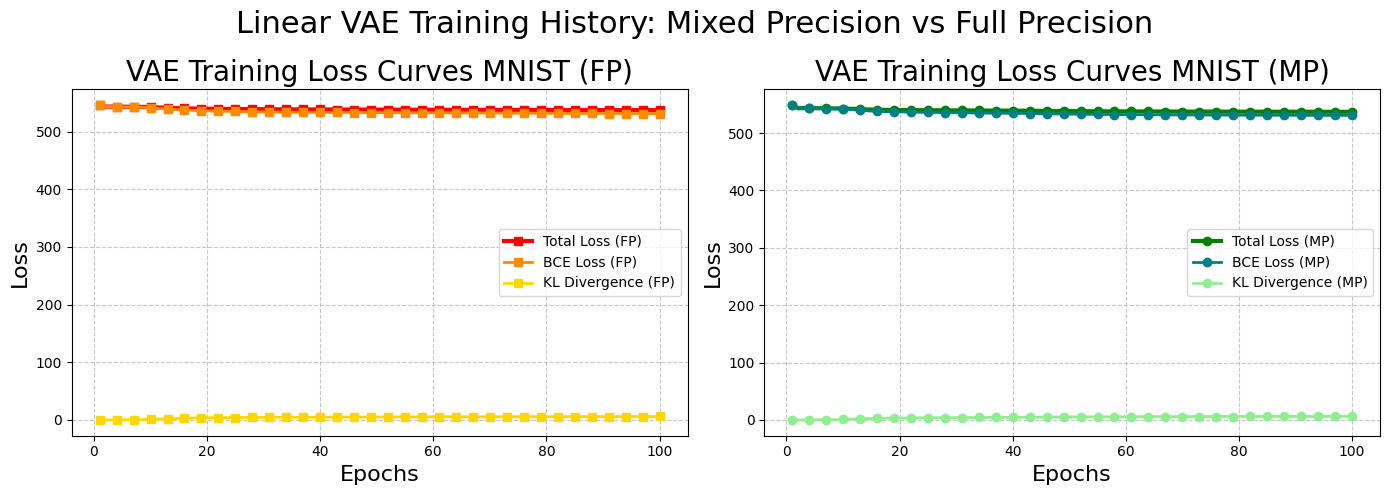

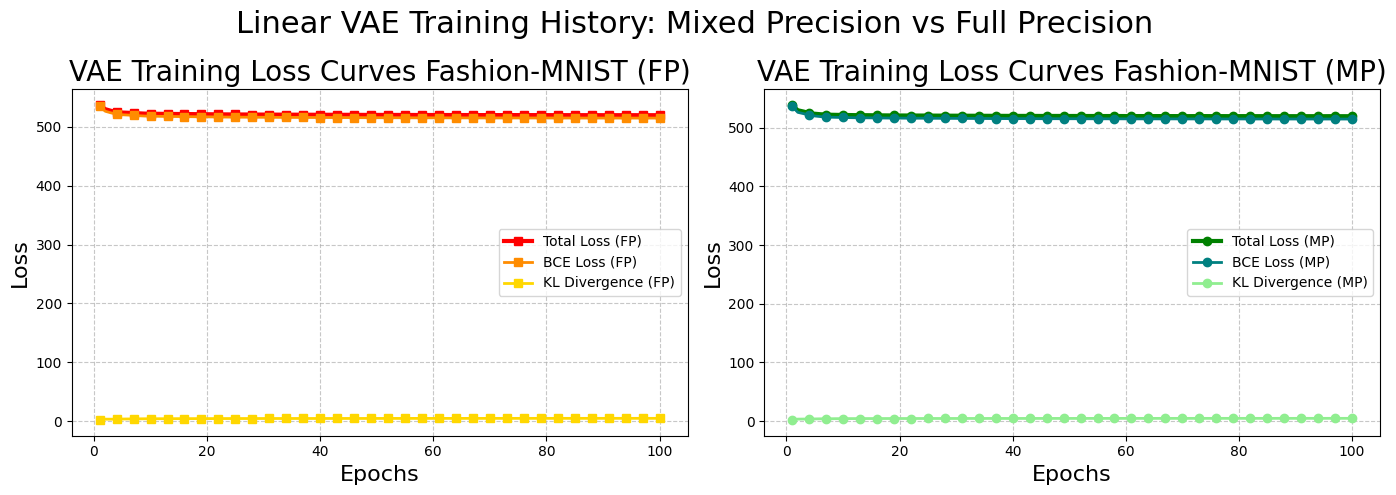

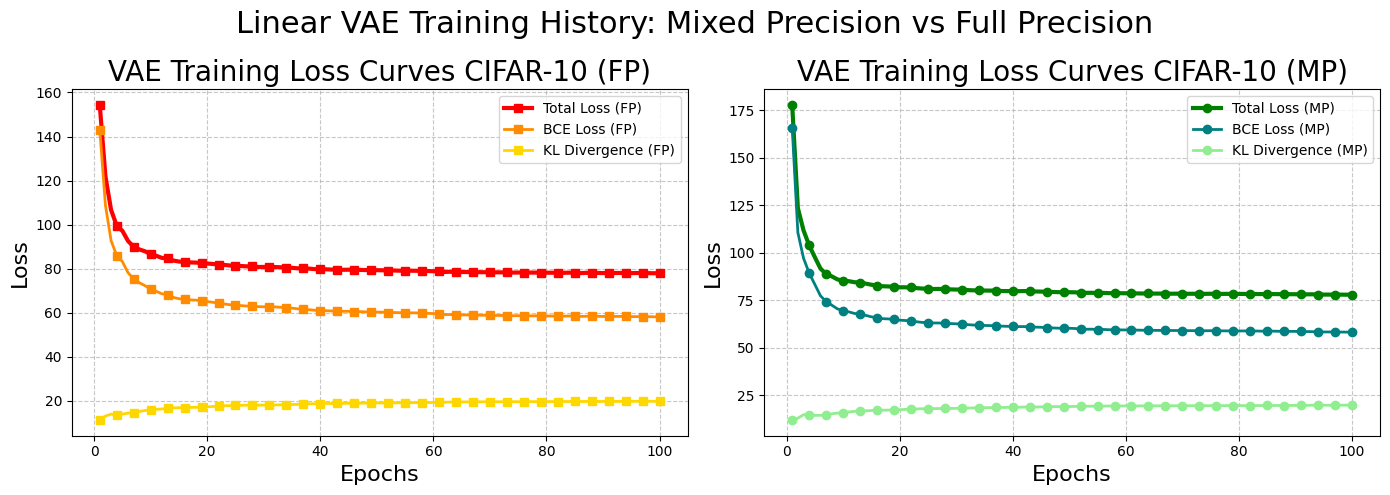

In [44]:
# Plotting the data from the trained, saved models

# conv VAE Training
plot_vae_history(vae_mnist_mp["history"], vae_mnist_fp["history"], subtitle="MNIST", main_title="ConvVAE Training History: Mixed Precision vs Full Precision")
plot_vae_history(vae_fmnist_mp["history"], vae_fmnist_fp["history"], subtitle="Fashion-MNIST", main_title="ConvVAE Training History: Mixed Precision vs Full Precision")
plot_vae_history(vae_cifar10_mp["history"], vae_cifar10_fp["history"], subtitle="CIFAR-10", main_title="ConvVAE Training History: Mixed Precision vs Full Precision")



# Linear VAE Training
plot_vae_history(vae_mnist_linear_mp["history"], vae_mnist_linear_fp["history"], subtitle="MNIST", main_title="Linear VAE Training History: Mixed Precision vs Full Precision")
plot_vae_history(vae_fmnist_linear_mp["history"], vae_fmnist_linear_fp["history"], subtitle="Fashion-MNIST", main_title="Linear VAE Training History: Mixed Precision vs Full Precision")
plot_vae_history(vae_cifar10_linear_mp["history"], vae_cifar10_linear_fp["history"], subtitle="CIFAR-10", main_title="Linear VAE Training History: Mixed Precision vs Full Precision")

In [ ]:
def evaluate_reconstruction_metrics( # SSIM and PSNR
    model, 
    dataloader,
    device=DEVICE,
    output_mode="prob",   # "prob", "logits", or "tanh"
    use_mixed_precision=False,
    max_batches=None
):
    model.eval()

    psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(device)
    ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

    autocast_enabled = use_mixed_precision and torch.cuda.is_available()
    autocast_device = "cuda" if torch.cuda.is_available() else "cpu"

    with torch.no_grad():
        for batch_idx, (x, _) in enumerate(dataloader):
            if max_batches is not None and batch_idx >= max_batches:
                break

            x = x.to(device)

            with torch.amp.autocast(device_type=autocast_device, enabled=autocast_enabled):
                output = model(x)
                x_hat = output[0] if isinstance(output, tuple) else output

            if output_mode == "logits":
                x_hat = torch.sigmoid(x_hat)
            elif output_mode == "tanh":
                x_hat = (x_hat + 1.0) / 2.0
            elif output_mode == "prob":
                pass
            else:
                raise ValueError("output_mode must be 'prob', 'logits', or 'tanh'")

            x_hat = torch.clamp(x_hat, 0.0, 1.0)
            x = torch.clamp(x, 0.0, 1.0)

            psnr_metric.update(x_hat, x)
            ssim_metric.update(x_hat, x)
           
        print("PSNR:", psnr_metric.compute().item())
        print("SSIM:", ssim_metric.compute().item())
def _history_value(history, *keys, default=None):
    for key in keys:
        if key in history and history[key] is not None:
            return history[key]
    return default


def _history_last(history, *keys, default=float("nan")):
    values = _history_value(history, *keys, default=None)
    if values is None:
        return default
    if isinstance(values, (list, tuple)) and len(values) > 0:
        return values[-1]
    return values

def print_vae_final_metrics(loaded_model, label):
    history = loaded_model["history"]

    print(f"Final Metrics {label}")
    print(f"Training time [s]:         {_history_value(history, 'Training_time', 'training_time', default=float('nan')):.4f}")
    print(f"Final train recon loss:    {_history_last(history, 'bce_loss'):.6f}")
    print(f"Final train KL loss:       {_history_last(history, 'kld_loss', 'train_vq_loss'):.6f}")
    print(f"Final train total loss:    {_history_last(history, 'train_loss'):.6f}")
    print(f"Final test recon loss:     {_history_last(history, 'test_recon_loss'):.6f}")
    print(f"Final test KL loss:        {_history_last(history, 'test_kl_loss', 'test_vq_loss'):.6f}")
    print(f"Final test total:          {_history_last(history, 'test_total_loss'):.6f}")
    print()

In [69]:
def plot_vae_test_total_loss_comparison(history_fp32, history_amp, title="Test Total Loss: FP32 vs Mixed Precision"):
    """
    Plot FP32 vs mixed precision loss curves.

    Priority:
    1) test_total_loss / total_test_loss / test_loss
    2) train_loss (fallback when test metrics are not stored)
    """
    def _select_curve(history, label):
        test_keys = ["test_total_loss", "total_test_loss", "test_loss"]
        train_fallback_keys = ["train_loss", "train_total_loss"]

        for key in test_keys:
            if key in history and isinstance(history[key], (list, tuple)) and len(history[key]) > 0:
                return np.asarray(history[key], dtype=float), key, "test"

        for key in train_fallback_keys:
            if key in history and isinstance(history[key], (list, tuple)) and len(history[key]) > 0:
                print(f"Warning: {label} has no test loss stored. Falling back to '{key}'.")
                return np.asarray(history[key], dtype=float), key, "train"

        available = sorted(history.keys())
        raise KeyError(
            f"No usable loss curve found for {label}. "
            f"Tried test keys {test_keys} and train fallback keys {train_fallback_keys}. "
            f"Available keys: {available}"
        )

    fp32_curve, fp32_key, fp32_kind = _select_curve(history_fp32, "FP32")
    amp_curve, amp_key, amp_kind = _select_curve(history_amp, "Mixed Precision")

    epochs_fp32 = np.arange(1, len(fp32_curve) + 1)
    epochs_amp = np.arange(1, len(amp_curve) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_fp32, fp32_curve, label=f"FP32 ({fp32_key})")
    plt.plot(epochs_amp, amp_curve, label=f"Mixed Precision ({amp_key})")

    y_kind = "Test" if (fp32_kind == "test" and amp_kind == "test") else "Train/Test (fallback used)"
    plt.xlabel("Epoch")
    plt.ylabel(f"{y_kind} Total Loss")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [60]:
# calculate PSNR and SSIM for ConvVAE on MNIST, Fashion-MNIST, and CIFAR-10 test sets, for both FP and MP models, and compare the results in a table format.
print("ConvVAE MNIST FP:")
evaluate_reconstruction_metrics(
    model=vae_mnist_fp["model"],
    dataloader=mnist_test,
    device=device,
    output_mode="prob",
    use_mixed_precision=False,
    max_batches=None  # use upper limit
)
print_vae_final_metrics(vae_mnist_fp, "ConvVAE MNIST FP")
print("----------------------------------------------------------")


print("\nConvVAE MNIST MP:")
evaluate_reconstruction_metrics( 
    model=vae_mnist_mp["model"],
    dataloader=mnist_test,
    device=device,
    output_mode="prob",
    use_mixed_precision=True,
    max_batches=None  # use upper limit
)
print_vae_final_metrics(vae_mnist_mp, "ConvVAE MNIST MP")
print("----------------------------------------------------------")

print("\nConvVAE Fashion-MNIST FP:")
evaluate_reconstruction_metrics(
    model=vae_fmnist_fp["model"],
    dataloader=fashion_mnist_test,
    device=device,
    output_mode="prob",
    use_mixed_precision=False,
    max_batches=None  # use upper limit
)
print_vae_final_metrics(vae_fmnist_fp, "ConvVAE Fashion-MNIST FP")
print("----------------------------------------------------------")

print("\nConvVAE Fashion-MNIST MP:")
evaluate_reconstruction_metrics(
    model=vae_fmnist_mp["model"],
    dataloader=fashion_mnist_test,
    device=device,
    output_mode="prob",
    use_mixed_precision=True,
    max_batches=None  # use upper limit
)
print_vae_final_metrics(vae_fmnist_mp, "ConvVAE Fashion-MNIST MP")
print("----------------------------------------------------------")

print("\nConvVAE CIFAR-10 FP:")
evaluate_reconstruction_metrics(
    model=vae_cifar10_fp["model"],
    dataloader=cifar10_test,
    device=device,
    output_mode="tanh",
    use_mixed_precision=False,
    max_batches=None
)
print_vae_final_metrics(vae_cifar10_fp, "ConvVAE CIFAR-10 FP")
print("----------------------------------------------------------")


print("\nConvVAE CIFAR-10 MP:")
evaluate_reconstruction_metrics(
    model=vae_cifar10_mp["model"],
    dataloader=cifar10_test,
    device=device,
    output_mode="tanh",
    use_mixed_precision=True,
    max_batches=None
)
print_vae_final_metrics(vae_cifar10_mp, "ConvVAE CIFAR-10 MP")
print("----------------------------------------------------------")


ConvVAE MNIST FP:
PSNR: 17.103168487548828
SSIM: 0.8015503287315369
Final Metrics ConvVAE MNIST FP
Training time [s]:         512.1691
Final train recon loss:    nan
Final train KL loss:       nan
Final train total loss:    nan
Final test recon loss:     nan
Final test KL loss:        nan
Final test total:          nan

----------------------------------------------------------

ConvVAE MNIST MP:
PSNR: 17.205780029296875
SSIM: 0.8080109357833862
Final Metrics ConvVAE MNIST MP
Training time [s]:         525.1136
Final train recon loss:    nan
Final train KL loss:       nan
Final train total loss:    nan
Final test recon loss:     nan
Final test KL loss:        nan
Final test total:          nan

----------------------------------------------------------

ConvVAE Fashion-MNIST FP:
PSNR: 13.18241024017334
SSIM: 0.4470216929912567
Final Metrics ConvVAE Fashion-MNIST FP
Training time [s]:         509.2768
Final train recon loss:    nan
Final train KL loss:       nan
Final train total loss: 

In [ ]:
# calculate PSNR and SSIM for linear VAE on MNIST, Fashion-MNIST, and CIFAR-10 test sets, for both FP and MP models, and compare the results in a table format.
print("linear VAE MNIST FP:")
evaluate_reconstruction_metrics(
    model=vae_mnist_linear_fp["model"],
    dataloader=mnist_test,
    device=device,
    output_mode="prob",
    use_mixed_precision=False,
    max_batches=None
)
print_vae_final_metrics(vae_mnist_linear_fp, label="linear VAE MNIST FP")
print("----------------------------------------------------------")

print("\nlinear VAE MNIST MP:")
evaluate_reconstruction_metrics( 
    model=vae_mnist_linear_mp["model"],
    dataloader=mnist_test,
    device=device,
    output_mode="prob",
    use_mixed_precision=True,
    max_batches=None
)
print_vae_final_metrics(vae_mnist_linear_mp, label="linear VAE MNIST MP")
print("----------------------------------------------------------")

print("\nlinear VAE Fashion-MNIST FP:")
evaluate_reconstruction_metrics(
    model=vae_fmnist_linear_fp["model"],
    dataloader=fashion_mnist_test,
    device=device,
    output_mode="prob",
    use_mixed_precision=False,
    max_batches=None
)
print_vae_final_metrics(vae_fmnist_linear_fp, label="linear VAE Fashion-MNIST FP")
print("----------------------------------------------------------")


print("\nlinear VAE Fashion-MNIST MP:")
evaluate_reconstruction_metrics(
    model=vae_fmnist_linear_mp["model"],
    dataloader=fashion_mnist_test,
    device=device,
    output_mode="prob",
    use_mixed_precision=True,
    max_batches=None
)
print_vae_final_metrics(vae_fmnist_linear_mp, label="linear VAE Fashion-MNIST MP")
print("----------------------------------------------------------")

print("\nlinear VAE CIFAR-10 FP:")
evaluate_reconstruction_metrics(
    model=vae_cifar10_linear_fp["model"],
    dataloader=cifar10_test,
    device=device,
    output_mode="tanh",
    use_mixed_precision=False,
    max_batches=None
)
print_vae_final_metrics(vae_cifar10_linear_fp, label="linear VAE CIFAR-10 FP")
print("----------------------------------------------------------")

print("\nlinear VAE CIFAR-10 MP:")
evaluate_reconstruction_metrics(
    model=vae_cifar10_linear_mp["model"],
    dataloader=cifar10_test,
    device=device,
    output_mode="tanh",
    use_mixed_precision=True,
    max_batches=None
)
print_vae_final_metrics(vae_cifar10_linear_mp, label="linear VAE CIFAR-10 MP")
print("----------------------------------------------------------")


linear VAE MNIST FP:
PSNR: 12.263611793518066
SSIM: 0.46865302324295044
Final Metrics linear VAE MNIST FP
Training time [s]:         497.8600
Final train recon loss:    nan
Final train KL loss:       nan
Final train total loss:    nan
Final test recon loss:     nan
Final test KL loss:        nan
Final test total:          nan

----------------------------------------------------------

linear VAE MNIST MP:
PSNR: 12.3723783493042
SSIM: 0.4835585951805115
Final Metrics linear VAE MNIST MP
Training time [s]:         520.5174
Final train recon loss:    nan
Final train KL loss:       nan
Final train total loss:    nan
Final test recon loss:     nan
Final test KL loss:        nan
Final test total:          nan

----------------------------------------------------------

linear VAE Fashion-MNIST FP:
PSNR: 11.544839859008789
SSIM: 0.3617490231990814
Final Metrics linear VAE Fashion-MNIST FP
Training time [s]:         497.7734
Final train recon loss:    nan
Final train KL loss:       nan
Final 

In [41]:
def _history_value(history, *keys, default=None):
    for key in keys:
        if key in history and history[key] is not None:
            return history[key]
    return default


def _history_last(history, *keys, default=float("nan")):
    values = _history_value(history, *keys, default=None)
    if values is None:
        return default
    if isinstance(values, (list, tuple)) and len(values) > 0:
        return values[-1]
    return values


def show_vae_results(history, test_loader=None, device=None, dataset_name="mnist", images=None, num_images=8):
    model = history["model"]
    model.eval()

    print("Final Metrics")
    print(f"Training time [s]:         {_history_value(history, 'Training_time', 'training_time', default=float('nan')):.4f}")
    print(f"Final train recon loss:    {_history_last(history, 'train_recon_loss'):.6f}")
    print(f"Final train KL loss:       {_history_last(history, 'train_kl_loss', 'train_vq_loss'):.6f}")
    print(f"Final train total loss:    {_history_last(history, 'train_total_loss'):.6f}")
    print(f"Final test recon loss:     {_history_last(history, 'test_recon_loss'):.6f}")
    print(f"Final test KL loss:        {_history_last(history, 'test_kl_loss', 'test_vq_loss'):.6f}")
    print(f"Final test total loss:     {_history_last(history, 'test_total_loss'):.6f}")

    if images is None:
        if test_loader is None or device is None:
            return
        images, _ = next(iter(test_loader))

    if device is None:
        raise ValueError("device must be provided when showing reconstructions")

    images = images[:num_images].to(device)

    with torch.no_grad():
        output = model(images)
        recon_data = output[0] if isinstance(output, tuple) else output

    images_vis = images.clamp(0, 1).cpu()
    recon_vis = to_display_tensor(recon_data, dataset_name)

    fig, axes = plt.subplots(2, num_images, figsize=(2 * num_images, 4))

    for i in range(num_images):
        original = images_vis[i]
        reconstructed = recon_vis[i]

        if original.shape[0] == 1:
            axes[0, i].imshow(original.squeeze(0), cmap="gray")
            axes[1, i].imshow(reconstructed.squeeze(0), cmap="gray")
        else:
            axes[0, i].imshow(original.permute(1, 2, 0))
            axes[1, i].imshow(reconstructed.permute(1, 2, 0))

        axes[0, i].axis("off")
        axes[1, i].axis("off")

    axes[0, 0].set_ylabel("Original", fontsize=12)
    axes[1, 0].set_ylabel("Recon", fontsize=12)

    plt.tight_layout()
    plt.show()


def denormalize_tensor(x, dataset_name="mnist"):
    if dataset_name in ["mnist", "fashion-mnist"]:
        mean = torch.tensor((0.5,), device=x.device).view(1, 1, 1, 1)
        std = torch.tensor((0.5,), device=x.device).view(1, 1, 1, 1)
    elif dataset_name == "cifar10":
        mean = torch.tensor((0.5, 0.5, 0.5), device=x.device).view(1, 3, 1, 1)
        std = torch.tensor((0.5, 0.5, 0.5), device=x.device).view(1, 3, 1, 1)
    else:
        raise ValueError(f"Unknown dataset: {dataset_name}")

    return x * std + mean


def moving_average(values, window=25):
    if values is None:
        return np.array([])
    if window is None or window <= 1 or len(values) < window:
        return np.array(values)
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="valid")


def show_vae_curves(history, extra_info, smooth_window=25, skip_first_batches=0):
    dataset_name = extra_info.get("dataset", "unknown dataset")
    precision_name = extra_info.get("precision", "unknown precision")
    title_prefix = f"{dataset_name} - {precision_name}"

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))

    train_recon_batch = _history_value(history, "train_recon_loss_batch", default=[])[skip_first_batches:]
    train_kl_batch = _history_value(history, "train_kl_loss_batch", "train_vq_loss_batch", default=[])[skip_first_batches:]
    train_total_batch = _history_value(history, "train_total_loss_batch", default=[])[skip_first_batches:]

    axes[0, 0].plot(moving_average(train_recon_batch, smooth_window), label="Train Recon")
    axes[0, 0].set_title(f"{title_prefix}\nBatch Reconstruction Loss")
    axes[0, 0].set_xlabel("Batch")
    axes[0, 0].set_ylabel("Loss")
    axes[0, 0].legend()

    axes[0, 1].plot(moving_average(train_kl_batch, smooth_window), label="Train KL")
    axes[0, 1].set_title(f"{title_prefix}\nBatch KL Loss")
    axes[0, 1].set_xlabel("Batch")
    axes[0, 1].set_ylabel("Loss")
    axes[0, 1].legend()

    axes[0, 2].plot(moving_average(train_total_batch, smooth_window), label="Train Total")
    axes[0, 2].set_title(f"{title_prefix}\nBatch Total Loss")
    axes[0, 2].set_xlabel("Batch")
    axes[0, 2].set_ylabel("Loss")
    axes[0, 2].legend()

    epochs = np.arange(1, 100)# len(history["train_total_loss"]) + 1)

    axes[1, 0].plot(epochs, history["train_recon_loss"], label="Train Recon")
    axes[1, 0].plot(epochs, history["test_recon_loss"], label="Test Recon")
    axes[1, 0].set_title(f"{title_prefix}\nEpoch Reconstruction Loss")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("Loss")
    axes[1, 0].legend()

    train_kl = _history_value(history, "train_kl_loss", "train_vq_loss", default=None)
    test_kl = _history_value(history, "test_kl_loss", "test_vq_loss", default=None)
    if train_kl is not None and test_kl is not None:
        axes[1, 1].plot(epochs, train_kl, label="Train KL")
        axes[1, 1].plot(epochs, test_kl, label="Test KL")
        axes[1, 1].legend()
    else:
        axes[1, 1].text(0.5, 0.5, "KL history not available", ha="center", va="center")
    axes[1, 1].set_title(f"{title_prefix}\nEpoch KL Loss")
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].set_ylabel("Loss")

    axes[1, 2].plot(epochs, history["train_total_loss"], label="Train Total")
    axes[1, 2].plot(epochs, history["test_total_loss"], label="Test Total")
    axes[1, 2].set_title(f"{title_prefix}\nEpoch Total Loss")
    axes[1, 2].set_xlabel("Epoch")
    axes[1, 2].set_ylabel("Loss")
    axes[1, 2].legend()

    plt.tight_layout()
    plt.show()

    if all(k in history for k in ["gpu_mem_allocated_mb", "gpu_mem_reserved_mb", "gpu_mem_peak_mb"]):
        plt.figure(figsize=(8, 4))
        plt.plot(history["gpu_mem_allocated_mb"], label="Allocated")
        plt.plot(history["gpu_mem_reserved_mb"], label="Reserved")
        plt.plot(history["gpu_mem_peak_mb"], label="Peak allocated")
        plt.xlabel("Epoch")
        plt.ylabel("Memory (MB)")
        plt.title(f"{title_prefix}\nGPU Memory Usage")
        plt.legend()
        plt.show()

def show_vae_total_loss(history, extra_info, smooth_window=25, skip_first_batches=0):
    dataset_name = extra_info.get("dataset", "unknown dataset")
    precision_name = extra_info.get("precision", "unknown precision")

    title_prefix = f"{dataset_name} - {precision_name}"

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    train_total_batch = _history_value(history, "train_total_loss_batch", default=[])[skip_first_batches:]
    axes[0].plot(moving_average(train_total_batch, smooth_window), label="Train Total")
    axes[0].set_title(f"{title_prefix}\nBatch Total Loss")
    axes[0].set_xlabel("Batch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    epochs = np.arange(1, len(history["train_total_loss"]) + 1)
    axes[1].plot(epochs, history["train_total_loss"], label="Train Total")
    axes[1].plot(epochs, history["test_total_loss"], label="Test Total")
    axes[1].set_title(f"{title_prefix}\nEpoch Total Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def print_vae_final_metrics(loaded_model, label):
    history = loaded_model["history"]

    print(f"Final Metrics {label}")
    print(f"Training time [s]:         {_history_value(history, 'Training_time', 'training_time', default=float('nan')):.4f}")
    print(f"Final train recon loss:    {_history_last(history, 'train_recon_loss'):.6f}")
    print(f"Final train KL loss:       {_history_last(history, 'train_kl_loss', 'train_vq_loss'):.6f}")
    print(f"Final train total loss:    {_history_last(history, 'train_total_loss'):.6f}")
    print(f"Final test recon loss:     {_history_last(history, 'test_recon_loss'):.6f}")
    print(f"Final test KL loss:        {_history_last(history, 'test_kl_loss', 'test_vq_loss'):.6f}")
    print(f"Final test total:          {_history_last(history, 'test_total_loss'):.6f}")
    print()


def plot_vae_test_total_loss_comparison(history_fp32, history_amp, title="Test Total Loss: FP32 vs Mixed Precision"):
    epochs_fp32 = np.arange(1, len(history_fp32["test_total_loss"]) + 1)
    epochs_amp = np.arange(1, len(history_amp["test_total_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_fp32, history_fp32["test_total_loss"], label="FP32")
    plt.plot(epochs_amp, history_amp["test_total_loss"], label="Mixed Precision")

    plt.xlabel("Epoch")
    plt.ylabel("Test Total Loss")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()



def show_vae_fixed_vs_mixed_results(
    fixed_history,
    mixed_history,
    test_loader=None,
    device=None,
    dataset_name="mnist",
    images=None,
    num_images=8,
    print_metrics=False,
):
    fixed_model = fixed_history["model"]
    mixed_model = mixed_history["model"]

    fixed_model.eval()
    mixed_model.eval()

    if print_metrics:
        print("===== FIXED PRECISION =====")
        print(f"Training time [s]:         {_history_value(fixed_history, 'Training_time', 'training_time', default=float('nan')):.4f}")
        print(f"Final train recon loss:    {_history_last(fixed_history, 'train_recon_loss'):.6f}")
        print(f"Final train KL loss:       {_history_last(fixed_history, 'train_kl_loss', 'train_vq_loss'):.6f}")
        print(f"Final train total loss:    {_history_last(fixed_history, 'train_total_loss'):.6f}")
        print(f"Final test recon loss:     {_history_last(fixed_history, 'test_recon_loss'):.6f}")
        print(f"Final test KL loss:        {_history_last(fixed_history, 'test_kl_loss', 'test_vq_loss'):.6f}")
        print(f"Final test total loss:     {_history_last(fixed_history, 'test_total_loss'):.6f}")

        print("\n===== MIXED PRECISION =====")
        print(f"Training time [s]:         {_history_value(mixed_history, 'Training_time', 'training_time', default=float('nan')):.4f}")
        print(f"Final train recon loss:    {_history_last(mixed_history, 'train_recon_loss'):.6f}")
        print(f"Final train KL loss:       {_history_last(mixed_history, 'train_kl_loss', 'train_vq_loss'):.6f}")
        print(f"Final train total loss:    {_history_last(mixed_history, 'train_total_loss'):.6f}")
        print(f"Final test recon loss:     {_history_last(mixed_history, 'test_recon_loss'):.6f}")
        print(f"Final test KL loss:        {_history_last(mixed_history, 'test_kl_loss', 'test_vq_loss'):.6f}")
        print(f"Final test total loss:     {_history_last(mixed_history, 'test_total_loss'):.6f}")

    if images is None:
        if test_loader is None:
            raise ValueError("Provide either images or test_loader")
        images, _ = next(iter(test_loader))

    if device is None:
        raise ValueError("device must be provided")

    images = images[:num_images].to(device)

    with torch.no_grad():
        fixed_output = fixed_model(images)
        mixed_output = mixed_model(images)

        fixed_recon = fixed_output[0] if isinstance(fixed_output, tuple) else fixed_output
        mixed_recon = mixed_output[0] if isinstance(mixed_output, tuple) else mixed_output

    # Originals from your dataloader are already in [0, 1]
    images_vis = images.detach().cpu().clamp(0.0, 1.0)

    # Reconstructions may be [0,1], [-1,1], or logits depending on model/dataset
    fixed_recon_vis = to_display_tensor(fixed_recon, dataset_name).cpu()
    mixed_recon_vis = to_display_tensor(mixed_recon, dataset_name).cpu()

    fig, axes = plt.subplots(3, num_images, figsize=(2 * num_images, 6))

    for i in range(num_images):
        original = images_vis[i]
        fixed_img = fixed_recon_vis[i]
        mixed_img = mixed_recon_vis[i]

        if original.shape[0] == 1:
            axes[0, i].imshow(original.squeeze(0), cmap="gray", vmin=0, vmax=1)
            axes[1, i].imshow(fixed_img.squeeze(0), cmap="gray", vmin=0, vmax=1)
            axes[2, i].imshow(mixed_img.squeeze(0), cmap="gray", vmin=0, vmax=1)
        else:
            axes[0, i].imshow(original.permute(1, 2, 0).clamp(0.0, 1.0))
            axes[1, i].imshow(fixed_img.permute(1, 2, 0).clamp(0.0, 1.0))
            axes[2, i].imshow(mixed_img.permute(1, 2, 0).clamp(0.0, 1.0))

        axes[0, i].axis("off")
        axes[1, i].axis("off")
        axes[2, i].axis("off")

    axes[0, 0].set_ylabel("Original", fontsize=12)
    axes[1, 0].set_ylabel("Fixed", fontsize=12)
    axes[2, 0].set_ylabel("Mixed", fontsize=12)

    plt.tight_layout()
    plt.show()

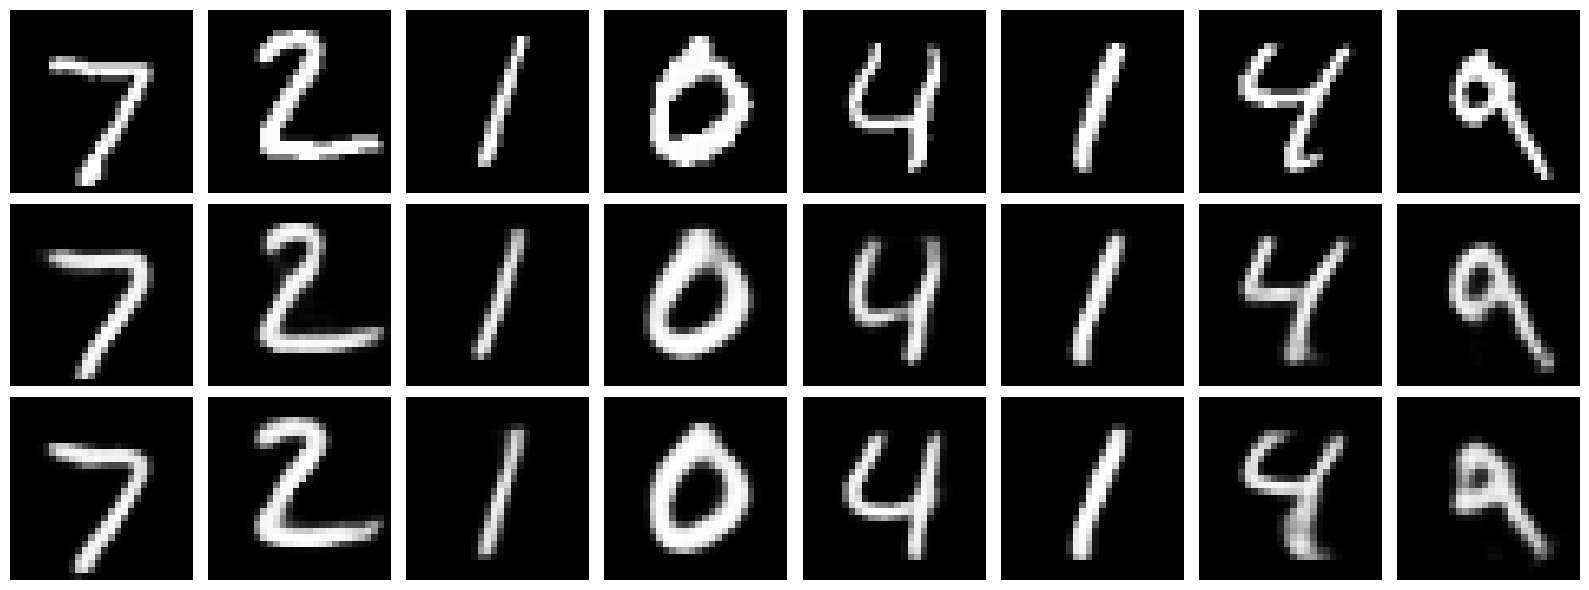

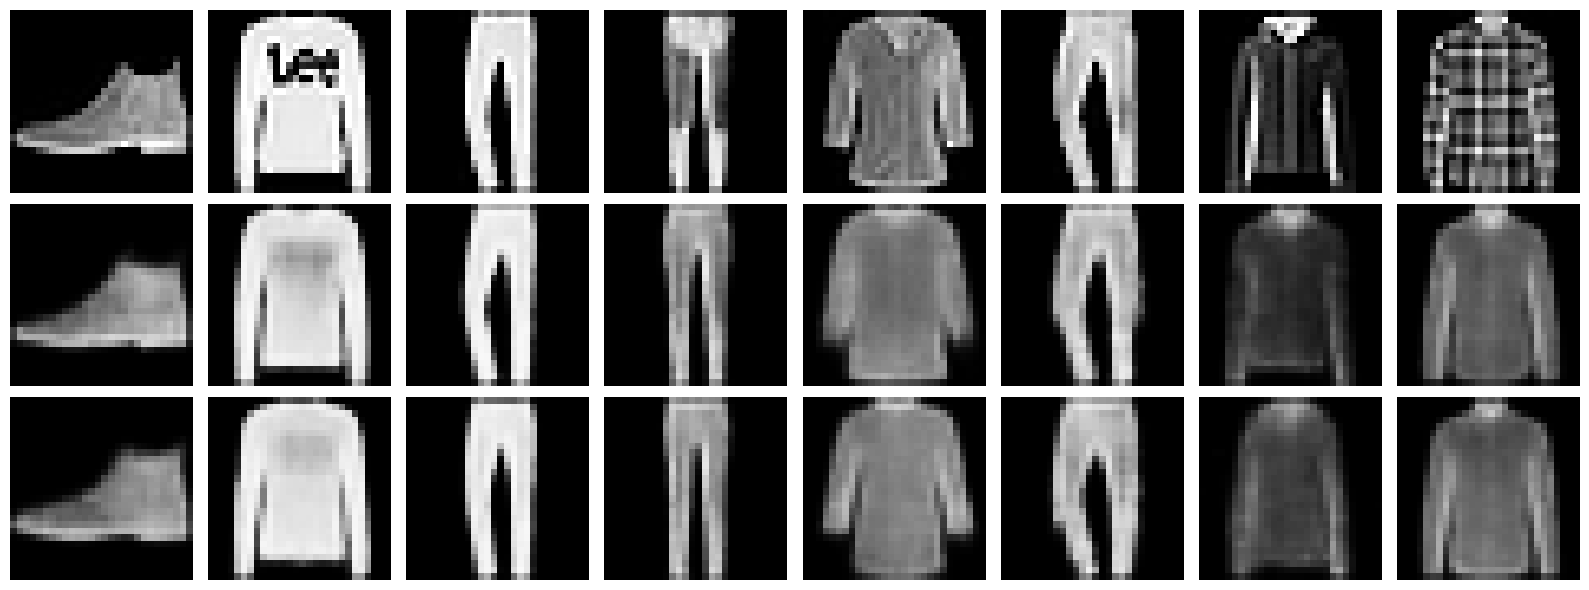

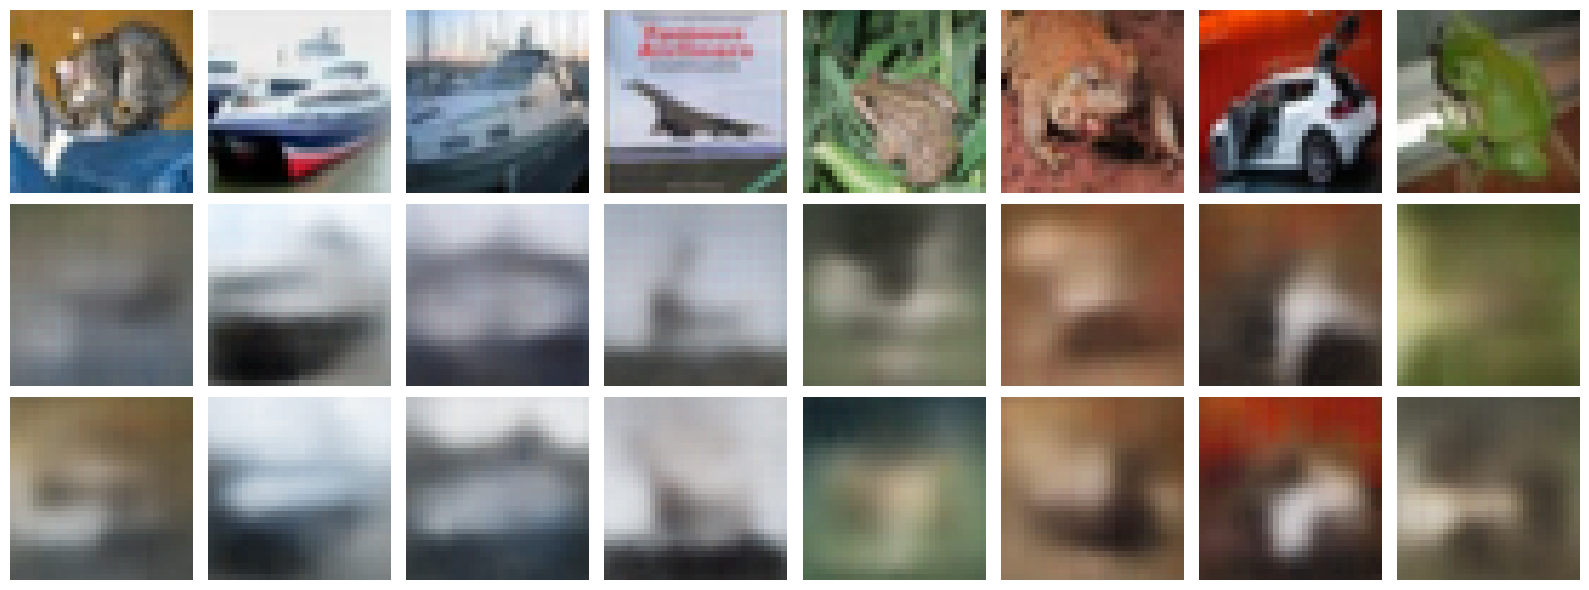

In [42]:
# conv VAE results

show_vae_fixed_vs_mixed_results(
    fixed_history=vae_mnist_fp,
    mixed_history=vae_mnist_mp,
    test_loader=mnist_test,
    device=device,
    dataset_name="mnist",
    num_images=8
)
show_vae_fixed_vs_mixed_results(
    fixed_history=vae_fmnist_fp,
    mixed_history=vae_fmnist_mp,
    test_loader=fashion_mnist_test,
    device=device,
    dataset_name="fashion-mnist",
    num_images=8
)
show_vae_fixed_vs_mixed_results(
    fixed_history=vae_cifar10_fp,
    mixed_history=vae_cifar10_mp,
    test_loader=cifar10_test,
    device=device,
    dataset_name="cifar10",
    num_images=8
)

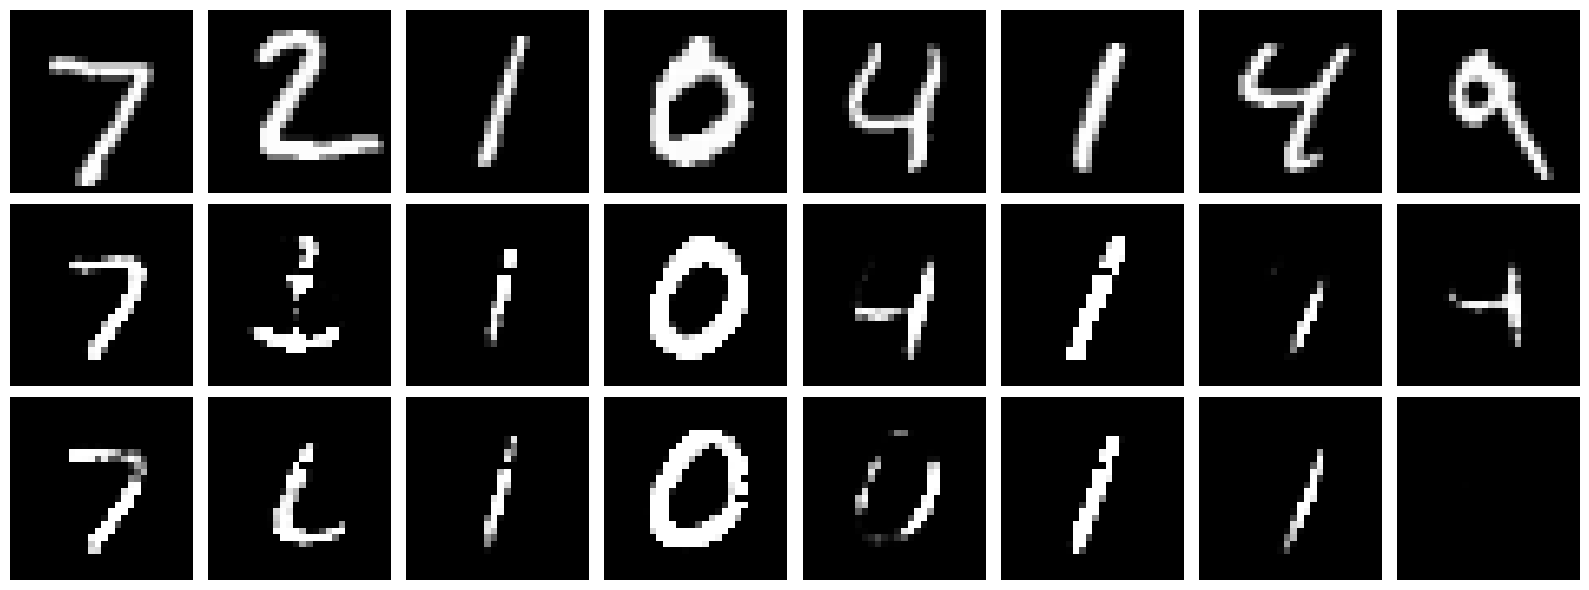

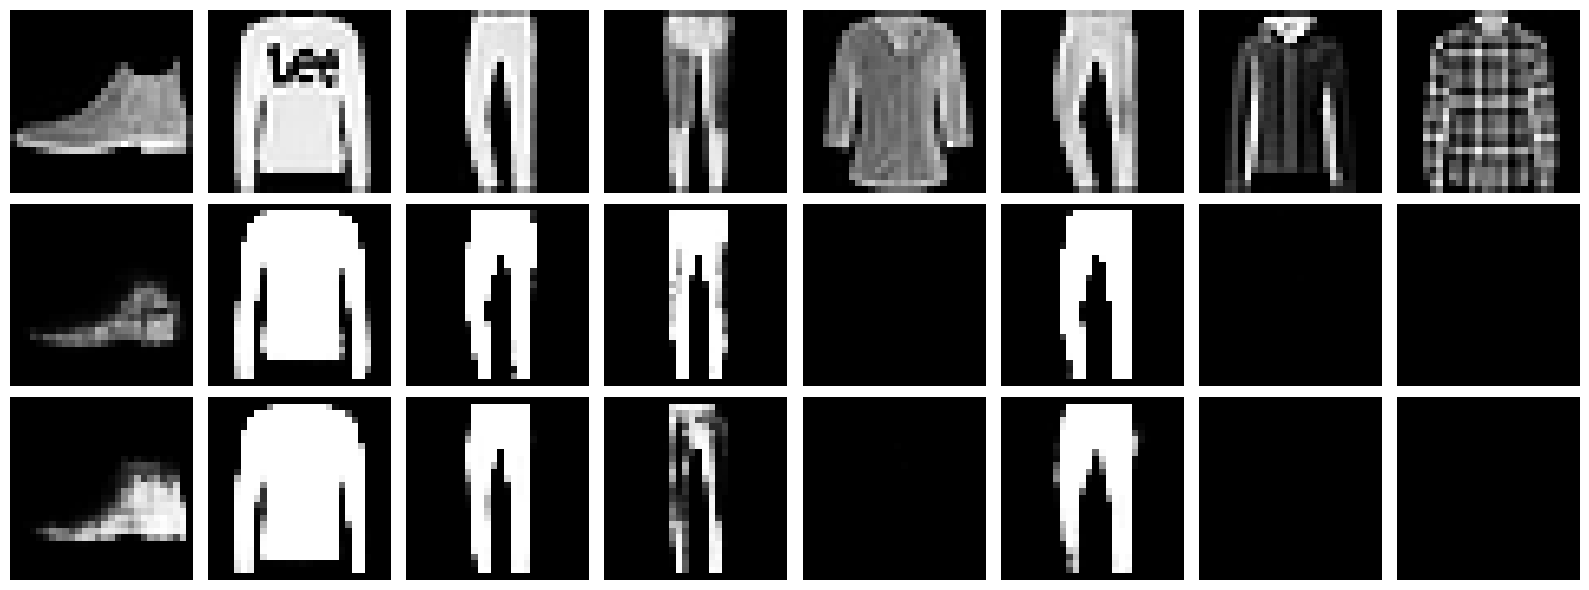

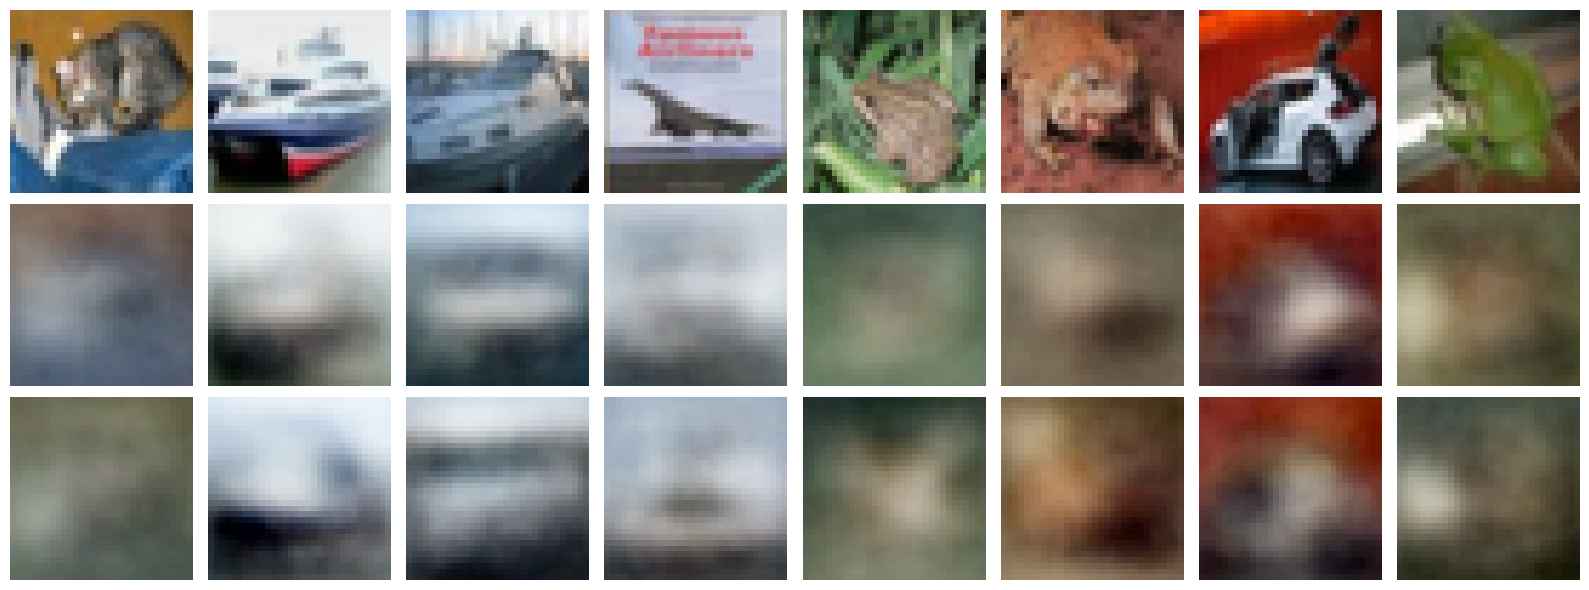

In [ ]:
# linear VAE results

show_vae_fixed_vs_mixed_results(
    fixed_history=vae_mnist_linear_fp,
    mixed_history=vae_mnist_linear_mp,
    test_loader=mnist_test,
    device=device,
    dataset_name="mnist",
    num_images=8
)

show_vae_fixed_vs_mixed_results(
    fixed_history=vae_fmnist_linear_fp,
    mixed_history=vae_fmnist_linear_mp,
    test_loader=fashion_mnist_test,
    device=device,
    dataset_name="fashion-mnist",
    num_images=8
)
show_vae_fixed_vs_mixed_results(
    fixed_history=vae_cifar10_linear_fp,
    mixed_history=vae_cifar10_linear_mp,
    test_loader=cifar10_test,
    device=device,
    dataset_name="cifar10",
    num_images=8
)

# Testing with test set

In [71]:
def evaluate_vae_test_losses(model, test_loader, dataset_name, device, use_mixed_precision=False):
    model.eval()
    total_loss = 0.0
    total_recon = 0.0
    total_kld = 0.0
    n_samples = 0

    autocast_enabled = use_mixed_precision and (device.type == "cuda")

    with torch.no_grad():
        for x, _ in test_loader:
            x = x.to(device)
            bsz = x.size(0)

            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=autocast_enabled):
                x_hat, mean, logvar = model(x)
                loss, recon, kld = vae_loss(x_hat, x, mean, logvar, dataset_name)

            total_loss += loss.item()
            total_recon += recon.item()
            total_kld += kld.item()
            n_samples += bsz

    return {
        "test_total_loss": total_loss / n_samples,
        "test_recon_loss": total_recon / n_samples,
        "test_kld_loss": total_kld / n_samples,
    }

    

In [ ]:
results = {}

results["conv_mnist_fp"] = evaluate_vae_test_losses(vae_mnist_fp["model"], mnist_test, "mnist", device, use_mixed_precision=False)
results["conv_mnist_mp"] = evaluate_vae_test_losses(vae_mnist_mp["model"], mnist_test, "mnist", device, use_mixed_precision=True)

results["conv_fmnist_fp"] = evaluate_vae_test_losses(vae_fmnist_fp["model"], fashion_mnist_test, "fashion-mnist", device, use_mixed_precision=False)
results["conv_fmnist_mp"] = evaluate_vae_test_losses(vae_fmnist_mp["model"], fashion_mnist_test, "fashion-mnist", device, use_mixed_precision=True)

results["conv_cifar_fp"] = evaluate_vae_test_losses(vae_cifar10_fp["model"], cifar10_test, "cifar10", device, use_mixed_precision=False)
results["conv_cifar_mp"] = evaluate_vae_test_losses(vae_cifar10_mp["model"], cifar10_test, "cifar10", device, use_mixed_precision=True)

pd.DataFrame(results).T

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x000001DEE74B2520>
Traceback (most recent call last):
  File "c:\Users\Nathan\OneDrive - Delft University of Technology\Documents\TU Delft\MASTER 1\Q3\Bayesian ML\Assignment 2\.venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "c:\Users\Nathan\OneDrive - Delft University of Technology\Documents\TU Delft\MASTER 1\Q3\Bayesian ML\Assignment 2\.venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1667, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'


,test_total_loss,test_recon_loss,test_kld_loss
conv_mnist_fp,98.308279,72.962388,25.345892
conv_mnist_mp,98.228200,72.579096,25.649104
conv_fmnist_fp,240.073655,222.683578,17.390077
conv_fmnist_mp,240.269092,223.084040,17.185053
conv_cifar_fp,73.947878,51.476314,22.471563
conv_cifar_mp,74.037863,51.245750,22.792113


In [73]:
# and for linear aswell
results_linear = {}
results_linear["linear_mnist_fp"] = evaluate_vae_test_losses(vae_mnist_linear_fp["model"], mnist_test, "mnist", device, use_mixed_precision=False)
results_linear["linear_mnist_mp"] = evaluate_vae_test_losses(vae_mnist_linear_mp["model"], mnist_test, "mnist", device, use_mixed_precision=True)

results_linear["linear_fmnist_fp"] = evaluate_vae_test_losses(vae_fmnist_linear_fp["model"], fashion_mnist_test, "fashion-mnist", device, use_mixed_precision=False)
results_linear["linear_fmnist_mp"] = evaluate_vae_test_losses(vae_fmnist_linear_mp["model"], fashion_mnist_test, "fashion-mnist", device, use_mixed_precision=True)

results_linear["linear_cifar_fp"] = evaluate_vae_test_losses(vae_cifar10_linear_fp["model"], cifar10_test, "cifar10", device, use_mixed_precision=False)
results_linear["linear_cifar_mp"] = evaluate_vae_test_losses(vae_cifar10_linear_mp["model"], cifar10_test, "cifar10", device, use_mixed_precision=True)

pd.DataFrame(results_linear).T

,test_total_loss,test_recon_loss,test_kld_loss
linear_mnist_fp,536.676125,530.790806,5.885320
linear_mnist_mp,536.536061,530.300498,6.235562
linear_fmnist_fp,520.020544,515.023249,4.997296
linear_fmnist_mp,519.909788,515.263727,4.646064
linear_cifar_fp,78.934692,59.597667,19.337025
linear_cifar_mp,79.440144,59.573042,19.867102
